# Text Analytics 2026 — Εργασία 3 (Ασκήσεις 4 & 5)

**Φοιτητές:**
* Νέγκι Χότζα — ΑΜ: p3352524
* Γιώργος Κωστόπουλος — ΑΜ: p3352520
* Αποστόλης Βελαόρας — ΑΜ: p3352527

---

## 0.0 Σκοπός του notebook

Αυτό το notebook υλοποιεί τις **Ασκήσεις 4 και 5** της τρίτης εργασίας του μαθήματος *Text Analytics*. Ακολουθούμε τα δύο εργαστήρια του μαθήματος:

* `TA2026_MLPs_torch.ipynb` (3ο demo) — μία **παραμετροποιημένη κλάση `CustomModel`** με optional Dropout / BatchNorm / LayerNorm, και σύγκριση BoW / TF-IDF / Word2Vec centroid features.
* `w2v_gensim.ipynb` — φόρτωση και χρήση **pre-trained word embeddings μέσω gensim** (Word2Vec, GloVe, FastText).

**Άσκηση 4** — sentiment classification στο NLTK *movie_reviews* με MLP σε PyTorch. Συγκρίνουμε με (i) majority classifier, και (ii) τον καλύτερο classifier της Άσκησης 11 της Εργασίας 2 (tuned logistic regression).

**Άσκηση 5** — **window-based MLP POS tagger** στο Universal Dependencies treebank (English-EWT). Συγκρίνουμε με baseline που επιστρέφει την πιο συχνή tag κάθε λέξης στο training.

Και στις δύο ασκήσεις αναφέρουμε **per-class και macro Precision / Recall / F1 / PR-AUC** σε train / dev / test, σχεδιάζουμε **καμπύλες train/dev loss**, και χτίζουμε **temporal-averaging ensemble** των top-$k$ best-dev-loss checkpoints.


## 0.1 Συνισφορά εργασίας
Η εργασία πραγματοποιήθηκε **συνεργατικά και ισάξια** και από τους τρεις φοιτητές. Όλοι συμμετείχαμε σε όλα τα στάδια — **φόρτωση και προεπεξεργασία δεδομένων** (NLTK movie_reviews για Άσκηση 4, UD English-EWT για Άσκηση 5), **σχεδιασμό και υλοποίηση** των MLP αρχιτεκτονικών σε PyTorch, **εκπαίδευση και hyperparameter tuning** στο dev set, **αξιολόγηση** με per-class και macro metrics, **οπτικοποίηση** (loss curves, bar charts, confusion matrix), **μαθηματικές παραγωγές** (back-propagation, softmax+CE gradient), **ερμηνεία αποτελεσμάτων** και **συγγραφή του report**. Κάθε ενότητα ελέγχθηκε από τουλάχιστον δύο μέλη της ομάδας για ορθότητα και πληρότητα.

## 0.2 Mental model — η συλλογιστική πορεία του notebook

Πριν προχωρήσουμε στον κώδικα, εδώ είναι μια εικόνα-σύνοψη της ροής και των βασικών αποφάσεων.

### Συνολική ροή pipeline

```text
                          ╔════════════════════════════════════╗
                          ║          GLOBAL SETUP              ║
                          ║  set_seed → device → metrics       ║
                          ╚═════════════════╤══════════════════╝
                                            │
                ┌───────────────────────────┴───────────────────────────┐
                ▼                                                       ▼
     ╔═══════════════════════╗                              ╔═══════════════════════╗
     ║      ΑΣΚΗΣΗ 4         ║                              ║      ΑΣΚΗΣΗ 5         ║
     ║  Sentiment (movie)    ║                              ║  POS Tagging (UD)     ║
     ╚═══════════╤═══════════╝                              ╚═══════════╤═══════════╝
                 │                                                      │
   load movie_reviews                                       parse CoNLL-U (read_conllu)
                 │                                                      │
   stratified 70/15/15 split                                build vocab + word2id
                 │                                                      │
   BoW / TF-IDF / W2V centroids                             load GloVe embeddings
                 │                                                      │
   2 baselines: majority + logreg                           1 baseline: most-freq-tag
                 │                                                      │
   15 MLP runs (5 arch × 3 rep)                             5 MLP runs (5 architectures)
                 │                                                      │
   for each run:                                            for each run:
     ┌─→ CustomModel(...)                                     ┌─→ WindowTagger(...)
     │   train_one_epoch  ──→  evaluate_loss                  │   train_one_epoch  ──→  evaluate_loss
     │           ↓                                            │           ↓
     │   loss.backward() ← softmax+CE gradient                │   loss.backward()
     │   optimizer.step() ← Adam                              │   optimizer.step()
     │           ↓                                            │           ↓
     │   if dev_loss < best_dev_loss:                         │   if dev_loss < best_dev_loss:
     │       save state_dict                                  │       save state_dict
     │           ↓                                            │           ↓
     │   keep all per-epoch states                            │   keep all per-epoch states
     │           ↓                                            │           ↓
     └── ReduceLROnPlateau (halves lr)                        └── ReduceLROnPlateau
                 │                                                      │
   pick best by DEV macro-F1                                pick best by DEV macro-F1
                 │                                                      │
   ensemble = average_states(top-5)                         ensemble = average_states(top-3)
                 │                                                      │
   evaluate train/dev/test                                  evaluate train/dev/test
                 │                                                      │
                 └─────────────────────┬────────────────────────────────┘
                                       ▼
                          ╔════════════════════════════════════╗
                          ║   §15.9 Σύνοψη + §16 Συζήτηση      ║
                          ╚════════════════════════════════════╝
```

### Σύνοψη όλων των `def` και `class` του notebook

| # | Όνομα | Είσοδος | Έξοδος | Σκοπός |
|---|---|---|---|---|
| 1 | `set_seed(seed)` | int | – | Αρχικοποιεί όλες τις πηγές τυχαιότητας (Python `random`, NumPy, PyTorch CPU & CUDA). Καθιστά τα splits και την αρχικοποίηση δικτύου deterministic. |
| 2 | `compute_metrics(y_true, y_pred, y_scores, label_ids, label_names)` | arrays | dict | Υπολογίζει per-class P/R/F1/AUC + macro averages. Επιστρέφει dict έτοιμο για pandas. |
| 3 | `one_hot_scores(n, predicted_label, n_classes)` | int, int, int | (n, K) array | Φτιάχνει deterministic one-hot scoring matrix για hard-prediction baselines, ώστε το PR-AUC να είναι ορισμένο. |
| 4 | `class CustomModel(nn.Module)` | input_dim, hidden_layers, dropout, batch_norm, layer_norm, classes_number | nn.Module | Παραμετροποιημένο MLP από το εργαστήριο. Μία κλάση καλύπτει Linear / Plain / Dropout / BN / LN. Σειρά block: `Linear → ReLU → optional(BN/LN/Dropout)`. |
| 5 | `train_one_epoch(model, loader, loss_fn, optimizer)` | model, DataLoader, loss, optim | float | Μία πλήρης πέρα από το train set: forward → backward (`loss.backward()`) → SGD step. Επιστρέφει το μέσο loss. |
| 6 | `evaluate_loss(model, loader, loss_fn)` | model, DataLoader, loss | float | Forward-only loss σε held-out set (no gradient). Χρησιμοποιείται για dev/test. |
| 7 | `predict_proba(model, loader, n_classes)` | model, DataLoader, int | (y_true, y_proba) | Τρέχει το μοντέλο σε ένα loader και επιστρέφει softmax πιθανότητες. Χρησιμοποιείται για evaluation. |
| 8 | `train_model(...)` | model, train_loader, dev_loader, lr, weight_decay, epochs | history, best_state, best_epoch, best_dev_loss | Το πλήρες training loop με Adam + ReduceLROnPlateau scheduler + best-dev checkpointing + per-epoch state retention. |
| 9 | `average_states(states)` | list of state_dicts | state_dict | Temporal averaging (Izmailov et al. 2018): μέσος όρος των weights πολλών checkpoints. Βάση του ensemble. |
| 10 | `plot_loss_curve(history, title, best_epoch)` | dict, str, int | – | Σχεδιάζει train (μπλε) και dev (πορτοκαλί) loss σε ένα panel με marker της best epoch. |
| 11 | `plot_loss_grid(runs, title)` | dict[name→run], str | – | Grid από πολλαπλά loss panels — ένα ανά αρχιτεκτονική/representation. |
| 12 | `plot_macro_bar(df, split, title)` | DataFrame, "dev"/"test", str | – | Horizontal bar chart του macro-F1 ανά μοντέλο. |
| 13 | `plot_per_class_f1(metrics_row, label_names, title)` | dict, list, str | – | Per-class F1 bar chart για το επιλεγμένο μοντέλο. |
| 14 | `plot_confmat(y_true, y_pred, label_ids, label_names, title)` | arrays, lists, str | – | Normalized confusion matrix (row-stochastic): entry $(i,j) = P(\hat y=j \mid y=i)$. |
| 15 | `split_stats(name, X, y)` | str, list, list | – | Τυπώνει στατιστικά (n, pos/neg counts, avg length) ανά split. |
| 16 | `_tokenize(text)` | str | list[str] | Tokenizer για W2V centroid computation: lowercase + split σε λέξεις. |
| 17 | `docs_to_centroids(docs, w2v, dim)` | list[str], KeyedVectors, int | (N, dim) array | Document → average of W2V vectors (centroid). OOV tokens αγνοούνται. |
| 18 | `to_loaders_dense(Xtr, ytr, Xdev, ydev, Xte, yte, batch_size)` | sparse/dense matrices | 3 DataLoaders | Μετατρέπει sparse → dense tensors και χτίζει DataLoaders για train/dev/test. |
| 19 | `read_conllu(path)` | str | list[(words, tags)] | Parser για CoNLL-U format του Universal Dependencies. Παρακάμπτει σχόλια & multi-word tokens. |
| 20 | `show_stats(sents, name)` | list, str | – | Τυπώνει στατιστικά corpus (sentences, words, avg/median/max length). |
| 21 | `baseline_predict_pos(sents)` | list[(w,t)] | (y_true, y_pred) | Most-frequent-tag baseline: κάθε λέξη παίρνει τη συχνότερη tag της στο train. OOV → NOUN. |
| 22 | `class POSWindowDataset(Dataset)` | sents, word2id, tag2id, radius | PyTorch Dataset | Κάθε token γίνεται window 2r+1 λέξεων (με `<PAD>` στα άκρα). Returns (window_ids, tag_id). |
| 23 | `class WindowTagger(nn.Module)` | vocab_size, emb_dim, window_len, custom_model_kwargs, embedding_init | nn.Module | Embedding (V×d, padding_idx=0) → flatten → CustomModel → 17-way logits. Καρδιά του POS tagger. |

### Συλλογιστική πορεία αποφάσεων (γιατί κάναμε ό,τι κάναμε)

1. **Γιατί CustomModel είναι μία κλάση αντί για 5 ξεχωριστές;**
   Επειδή θέλουμε **apples-to-apples σύγκριση** μεταξύ Linear / Dropout / BN / LN. Με μία κλάση και flags είμαστε σίγουροι ότι η μόνη διαφορά μεταξύ runs είναι το normalization, όχι η αρχιτεκτονική του block ή το init.

2. **Γιατί best-dev-loss checkpointing αντί για early stopping;**
   Early stopping σταματά νωρίς και χάνει το πλήρες loss curve που χρειαζόμαστε για διαγνωστικά (Section 9.1). Best-dev-loss checkpointing εκπαιδεύει για όλες τις epochs αλλά **διατηρεί τα weights της καλύτερης epoch** — έχουμε και το πλήρες diagnostic και την προστασία από overfitting.

3. **Γιατί κρατάμε ALL per-epoch states (όχι μόνο το best);**
   Για το temporal-averaging ensemble (Izmailov et al. 2018). Το ensemble δεν είναι των top-1 αλλά των top-k checkpoints από όλο το training, οπότε χρειαζόμαστε τα state_dicts όλων των epochs.

4. **Γιατί 3 διαφορετικά representations (BoW/TF-IDF/W2V);**
   Για να ελέγξουμε **πόσο εξαρτάται η επιτυχία από το feature space**. Αν όλα έδιναν ίδιο F1, το feature engineering δεν παίζει ρόλο. Στην πράξη βλέπουμε ότι TF-IDF νικάει — άρα το feature engineering είναι όσο σημαντικό όσο η αρχιτεκτονική.

5. **Γιατί window features;**
   Το window radius=2 είναι το standard για POS tagging με MLPs — μικρό αρκετά ώστε να μην εκραγεί το input dim, αρκετά μεγάλο ώστε να συλλάβει τα immediate context patterns.

6. **Γιατί padding_idx=0 στο Embedding;**
   Το `<PAD>` token δεν πρέπει να λάβει gradient ή να επηρεάσει το training. Με `padding_idx=0`, το PyTorch αυτόματα μηδενίζει το gradient του row 0 του embedding matrix.

7. **Γιατί macro-F1 αντί για accuracy;**
   Στην Άσκηση 5 το dataset είναι **πολύ unbalanced** (NOUN ≈ 17%, X ≈ 0.4%). Το accuracy και το weighted-F1 δίνουν artificially υψηλά νούμερα ακόμα και αν αγνοούμε rare classes. Το macro-F1 τιμωρεί ομοιόμορφα — δείχνει την πραγματική ικανότητα γενίκευσης σε όλες τις POS.

8. **Γιατί ReduceLROnPlateau scheduler;**
   Όταν το dev loss σταματά να βελτιώνεται, η εκπαίδευση συνήθως έχει φτάσει σε plateau. Υποδιπλασιάζοντας το lr, το μοντέλο μπορεί να κάνει finer adjustments γύρω από τοπικό ελάχιστο. Συχνά δίνει +0.005-0.01 macro-F1 χωρίς extra runtime.

9. **Γιατί επιλογή best πάντα από dev set;**
   Test set leakage. Αν επιλέγαμε με βάση το test, τότε το reported test F1 θα ήταν **biased upward** και δεν θα αντικατόπτριζε την πραγματική γενίκευση σε άγνωστα δεδομένα. Standard ML hygiene.


## 1. Global setup

### 1.1 Imports

Χρησιμοποιούμε τη standard scientific Python στοίβα (`numpy`, `pandas`, `matplotlib`), το `scikit-learn` (TF-IDF, logistic regression, metric helpers), το `nltk` (movie_reviews corpus για Άσκηση 4) και **PyTorch** για τα MLPs. Επίσης το `gensim` για τα pre-trained embeddings.


In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 33.0 MB/s eta 0:00:00


In [ ]:
# === Standard library ===
import os, sys, math, time, copy, random, itertools, json, pathlib, urllib.request
from collections import Counter, defaultdict

# === Scientific stack ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === PyTorch ===
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, TensorDataset, DataLoader

# === scikit-learn ===
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (precision_recall_fscore_support,
                             average_precision_score,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import label_binarize


### 1.2 Επαναληψιμότητα, device, fast mode

Θέτουμε seed στα `random`, `numpy` και PyTorch (CPU + CUDA) ώστε τα splits και οι αρχικοποιήσεις του δικτύου να είναι αναπαραγώγιμα.

Αυτόματο device detection:
* αν υπάρχει διαθέσιμη CUDA GPU (π.χ. Colab T4) τη χρησιμοποιούμε,
* αλλιώς πέφτουμε σε CPU.

Το `FAST_MODE` είναι switch για development: μικραίνει τα epochs και παρακάμπτει τα gensim downloads. **Για το τελικό report είναι `FAST_MODE = False`**, ιδανικά σε Colab GPU runtime.


In [ ]:
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# === FAST_MODE switch ===
# True  → small grid, few epochs, no pretrained embeddings download (CPU-friendly)
# False → full sweep, more epochs, gensim downloads (Colab GPU)
FAST_MODE =  torch.cuda.is_available()
print("FAST_MODE:", FAST_MODE)


Using device: cpu
FAST_MODE: False


### 1.3 Συναρτήσεις υπολογισμού metrics

Η εργασία απαιτεί **per-class** και **macro-averaged** **Precision, Recall, F1 και Precision–Recall AUC** σε train / dev / test.

**Precision** της κλάσης $c$:
$$
P_c \;=\; \frac{\mathrm{TP}_c}{\mathrm{TP}_c+\mathrm{FP}_c}
$$
*(από τα παραδείγματα που προβλέψαμε ως $c$, πόσα ήταν πράγματι $c$).*

**Recall** της κλάσης $c$:
$$
R_c \;=\; \frac{\mathrm{TP}_c}{\mathrm{TP}_c+\mathrm{FN}_c}
$$
*(από τα παραδείγματα που είναι πράγματι $c$, πόσα ανιχνεύσαμε).*

**F1** της κλάσης $c$ — αρμονικός μέσος των $P$ και $R$:
$$
F1_c \;=\; \frac{2\,P_c\,R_c}{P_c+R_c}
$$
*(τιμωρεί την ανισορροπία μεταξύ precision και recall — αν ένα από τα δύο πέσει χαμηλά, ολόκληρο το F1 πέφτει).*

**Average Precision / PR-AUC** της κλάσης $c$ — εμβαδό κάτω από την precision–recall καμπύλη, που προκύπτει σαρώνοντας το threshold στην προβλεπόμενη πιθανότητα:
$$
AP_c \;=\; \sum_n (R_n-R_{n-1})\,P_n .
$$

Για probabilistic classifiers χρησιμοποιούμε τις softmax πιθανότητες· για τα hard-prediction baselines κατασκευάζουμε ένα deterministic one-hot "score" matrix ώστε το PR-AUC να είναι καλά ορισμένο.

**Macro averages** — *unweighted* μέσος όρος πάνω στις $K$ κλάσεις:
$$
\text{macro-}M = \frac{1}{K}\sum_{c=1}^{K} M_c, \quad M\in\{P,R,F1,AP\}.
$$

Το macro επιλέγεται **επίτηδες** αντί για micro-/weighted-averaging, γιατί:
* τιμωρεί δυσανάλογα μοντέλα που αγνοούν rare classes (π.χ. το "X" tag στο POS),
* όλες οι κλάσεις βαρύνουν ισόποσα ανεξαρτήτως μεγέθους.


In [ ]:
def compute_metrics(y_true, y_pred, y_scores, label_ids, label_names):
    # Per-class precision / recall / F1
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=label_ids, zero_division=0)

    # One-vs-rest binarisation for the PR-AUC computation
    y_true_bin = label_binarize(y_true, classes=label_ids)
    if y_true_bin.shape[1] == 1:                  # binary corner case
        y_true_bin = np.column_stack([1 - y_true_bin, y_true_bin])

    pr_auc = []
    for i, lid in enumerate(label_ids):
        # A class can be entirely absent from y_true (rare for POS tags).
        # average_precision_score is undefined in that case → NaN.
        if y_true_bin[:, i].sum() == 0:
            pr_auc.append(float('nan'))
        else:
            pr_auc.append(average_precision_score(y_true_bin[:, i],
                                                  y_scores[:, i]))
    pr_auc = np.array(pr_auc)

    row = {}
    for i, name in enumerate(label_names):
        row[f"P[{name}]"]   = precision[i]
        row[f"R[{name}]"]   = recall[i]
        row[f"F1[{name}]"]  = f1[i]
        row[f"AUC[{name}]"] = pr_auc[i]
    row["macro_P"]   = float(np.nanmean(precision))
    row["macro_R"]   = float(np.nanmean(recall))
    row["macro_F1"]  = float(np.nanmean(f1))
    row["macro_AUC"] = float(np.nanmean(pr_auc))
    return row


def one_hot_scores(n, predicted_label, n_classes):
    s = np.zeros((n, n_classes))
    s[:, predicted_label] = 1.0
    return s


## 2. Η κλάση `CustomModel` (από το εργαστήριο)

Αυτό είναι το **παραμετροποιημένο MLP** από το 3ο demo του μαθήματος (`TA2026_MLPs_torch.ipynb`). Μία κλάση καλύπτει όλες τις αρχιτεκτονικές που πρέπει να συγκρίνουμε:

| Variant | hidden layers | Dropout | BatchNorm | LayerNorm |
|---|---|---|---|---|
| Linear        | –       | 0   | – | – |
| Plain MLP     | δοθέν   | 0   | – | – |
| MLP+Dropout   | δοθέν   | > 0 | – | – |
| MLP+BatchNorm | δοθέν   | 0   | ✓ | – |
| MLP+LayerNorm | δοθέν   | 0   | – | ✓ |

### 2.1 Μαθηματικό μοντέλο

Για ένα δίκτυο με $L$ κρυφά layers διαστάσεων $d_1,\dots,d_L$:

$$
\mathbf{h}_0 = \mathbf{x},\qquad
\mathbf{h}_\ell = \phi\!\bigl(N\bigl(\mathbf{W}_\ell\mathbf{h}_{\ell-1}+\mathbf{b}_\ell\bigr)\bigr),
\quad \ell = 1,\dots,L,
$$

όπου $\phi(z)=\max(0,z)$ είναι η **ReLU** non-linearity και $N(\cdot)$ είναι είτε identity (Plain MLP), είτε **BatchNorm**

$$
N_{\text{BN}}(z_i) = \gamma\,\frac{z_i-\mu_B}{\sqrt{\sigma_B^2+\epsilon}} + \beta
$$

(τα στατιστικά υπολογίζονται πάνω στο batch dimension), είτε **LayerNorm**

$$
N_{\text{LN}}(z_i) = \gamma\,\frac{z_i-\mu_L}{\sqrt{\sigma_L^2+\epsilon}} + \beta
$$

(τα στατιστικά πάνω στο *feature dimension* του κάθε παραδείγματος).

Το **Dropout** μηδενίζει τυχαία activations κατά το training με πιθανότητα $p$ και πολλαπλασιάζει τα survivors με $1/(1-p)$ ώστε η αναμενόμενη τιμή να παραμένει ίδια (inverted dropout):

$$
\tilde h_{\ell,i} = \frac{m_{\ell,i}}{1-p}\,h_{\ell,i},\qquad m_{\ell,i}\sim\text{Bernoulli}(1-p).
$$

Το output layer είναι

$$
\mathbf{o} = \mathbf{W}_{L+1}\mathbf{h}_L+\mathbf{b}_{L+1} \in \mathbb{R}^K
$$

(χωρίς activation· η softmax εφαρμόζεται μέσα στο loss).

### 2.2 Γιατί αυτές οι τέσσερις επιλογές κανονικοποίησης;

* **Χωρίς norm + χωρίς dropout (Plain MLP)** — απλούστερο baseline.
* **Dropout** — προσθέτει θόρυβο· εμποδίζει co-adaptation των νευρώνων· αποτελεσματικό όταν το feature dim είναι υψηλό (TF-IDF με 5–20k features).
* **BatchNorm** — κανονικοποιεί πάνω στο batch· πολύ αποτελεσματικό για βαθιά feed-forward δίκτυα, αλλά τα στατιστικά εξαρτώνται από το batch size, οπότε υποφέρει σε μικρά ή non-i.i.d. batches.
* **LayerNorm** — κανονικοποιεί πάνω στο feature dim του κάθε παραδείγματος· **ανεξάρτητο** από batch size· καταλληλότερο για variable-length inputs (π.χ. το window-MLP του POS).


In [ ]:
class CustomModel(nn.Module):
    # Parameterised MLP from the lab (TA2026_MLPs_torch.ipynb).
    # Covers: Linear / Plain / Dropout / BatchNorm / LayerNorm variants.
    def __init__(self, input_dim, hidden_layers=None,
                 dropout=0.0, batch_norm=False, layer_norm=False,
                 classes_number=None, model_id=None):
        super().__init__()
        layers, prev = [], input_dim
        if hidden_layers:
            for h in hidden_layers:
                layers.append(nn.Linear(prev, h))
                layers.append(nn.ReLU())
                if batch_norm: layers.append(nn.BatchNorm1d(h))
                if layer_norm: layers.append(nn.LayerNorm(h))
                if dropout > 0: layers.append(nn.Dropout(dropout))
                prev = h
        layers.append(nn.Linear(prev, classes_number))
        self.net = nn.Sequential(*layers)

        # Build a readable identifier for logging / checkpoint filenames.
        if model_id is None:
            parts = ["mlp"]
            if hidden_layers: parts.append("h" + "-".join(str(h) for h in hidden_layers))
            if dropout > 0:   parts.append(f"drop{dropout}")
            if batch_norm:    parts.append("bn")
            if layer_norm:    parts.append("ln")
            model_id = "_".join(parts)
        self.model_id = model_id
        self.config = dict(input_dim=input_dim, hidden_layers=hidden_layers or [],
                           dropout=dropout, batch_norm=batch_norm,
                           layer_norm=layer_norm, classes_number=classes_number)

    def forward(self, x):
        return self.net(x)


## 3. Συναρτήσεις training & evaluation

Το training loop είναι αυτό του εργαστηρίου, επεκταμένο με:

* per-epoch logging του **train *και* dev** loss,
* **best-epoch checkpointing** με κριτήριο το dev loss,
* διατήρηση όλων των per-epoch state-dicts ώστε να μπορούμε αργότερα να χτίσουμε το temporal-averaging ensemble,
* optional **learning-rate scheduler** (`ReduceLROnPlateau`) που υποδιπλασιάζει το lr όταν το dev loss σταματά να βελτιώνεται.

### 3.1 Loss — categorical cross-entropy

Για ένα παράδειγμα με σωστό label $y$ και logits $\mathbf{o}$:

$$
\mathcal{L}(\theta) = -\log\,p_y(\mathbf{x}) = -o_y + \log\sum_k e^{o_k}.
$$

Για ένα mini-batch το loss είναι ο μέσος όρος πάνω στα $B$ παραδείγματα. Όταν περάσουμε `weight_decay > 0` στον Adam, προστίθεται implicit L2 penalty $\frac{\lambda}{2}\lVert\theta\rVert_2^2$.

### 3.2 Optimizer — Adam

Ο Adam κρατάει running estimates του gradient mean και variance, τα bias-corrects, και ενημερώνει τις παραμέτρους:

$$
\theta_{t+1} = \theta_t - \eta\,\frac{\hat m_t}{\sqrt{\hat v_t}+\epsilon}.
$$

Default τιμές: $\beta_1=0.9,\beta_2=0.999,\epsilon=10^{-8}$.


In [ ]:
def train_one_epoch(model, loader, loss_fn, optimizer):
    # One full pass over the training data, with back-prop and SGD step.
    model.train(); total = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        optimizer.step()
        total += loss.item() * xb.size(0)
    return total / len(loader.dataset)


def evaluate_loss(model, loader, loss_fn):
    # Forward-only loss on a held-out set (no gradient).
    model.eval(); total = 0.0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            total += loss_fn(model(xb), yb).item() * xb.size(0)
    return total / len(loader.dataset)


def predict_proba(model, loader, n_classes):
    # Run the model on a loader, return (true labels, softmax probabilities).
    model.eval(); ys, ps = [], []
    with torch.no_grad():
        for xb, yb in loader:
            p = torch.softmax(model(xb.to(DEVICE)), dim=1).cpu().numpy()
            ps.append(p); ys.append(yb.numpy())
    return np.concatenate(ys), np.concatenate(ps)


def train_model(model, train_loader, dev_loader, *,
                lr=1e-3, weight_decay=0.0, epochs=20, verbose=True,
                use_scheduler=True):
    # Adam + (optional) ReduceLROnPlateau LR scheduler. Returns:
    #   history       — dict with per-epoch train/dev losses and state-dicts
    #   best_state    — state-dict at the epoch with minimal dev loss
    #   best_epoch    — that epoch index (1-based)
    #   best_dev_loss — its dev loss value
    loss_fn   = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=lr, weight_decay=weight_decay)
    scheduler = (torch.optim.lr_scheduler.ReduceLROnPlateau(
                     optimizer, mode='min', factor=0.5, patience=2)
                 if use_scheduler else None)

    history = {"train": [], "dev": [], "states": [], "lr": []}
    best_state, best_dev_loss, best_epoch = None, float("inf"), -1
    for ep in range(1, epochs + 1):
        tr = train_one_epoch(model, train_loader, loss_fn, optimizer)
        dv = evaluate_loss(model, dev_loader,  loss_fn)
        if scheduler is not None:
            scheduler.step(dv)
        history["train"].append(tr); history["dev"].append(dv)
        history["lr"].append(optimizer.param_groups[0]["lr"])
        history["states"].append(copy.deepcopy(model.state_dict()))
        if dv < best_dev_loss:
            best_dev_loss, best_state, best_epoch = dv, history["states"][-1], ep
        if verbose and (ep <= 3 or ep % max(1, epochs // 6) == 0 or ep == epochs):
            print(f"  Epoch {ep:3d} | train {tr:.4f} | dev {dv:.4f}"
                  f" | lr {optimizer.param_groups[0]['lr']:.1e}")
    return history, best_state, best_epoch, best_dev_loss


def average_states(states):
    # Temporal averaging (Izmailov et al., 2018): average the parameters
    # across a set of checkpoints. Returns a new state-dict.
    avg = copy.deepcopy(states[0])
    for k in avg:
        if torch.is_floating_point(avg[k]):
            stk = torch.stack([s[k].float() for s in states])
            avg[k] = stk.mean(0).to(avg[k].dtype)
    return avg


## 4. Συναρτήσεις σχεδίασης

Επαναχρησιμοποιήσιμες plotting functions ώστε οι ενότητες Άσκησης 4 και 5 να μένουν καθαρές.


In [ ]:
def plot_loss_curve(history, title, best_epoch=None):
    # Single train/dev loss panel (like the screenshots from the lab).
    fig, ax = plt.subplots(figsize=(7, 4))
    xs = range(1, len(history["train"]) + 1)
    ax.plot(xs, history["train"], label="train loss", color="C0")
    ax.plot(xs, history["dev"],   label="dev loss",   color="C1")
    if best_epoch is not None:
        ax.axvline(best_epoch, color='gray', linestyle=':',
                   label=f"best dev epoch = {best_epoch}")
    ax.set_xlabel("epoch"); ax.set_ylabel("cross-entropy loss")
    ax.set_title(title); ax.grid(alpha=.3); ax.legend()
    plt.tight_layout(); plt.show()


def plot_loss_grid(runs, title):
    # One subplot per model.  `runs` is a dict name -> dict(history=..., best_epoch=...).
    n = len(runs)
    ncols = min(3, n); nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.5*nrows),
                             sharey=True)
    axes = np.atleast_1d(axes).ravel()
    for ax, (name, run) in zip(axes, runs.items()):
        h = run["history"]
        xs = range(1, len(h["train"]) + 1)
        ax.plot(xs, h["train"], label="train", color="C0")
        ax.plot(xs, h["dev"],   label="dev",   color="C1")
        ax.axvline(run["best_epoch"], color='gray', linestyle=':')
        ax.set_title(name, fontsize=10)
        ax.set_xlabel("epoch"); ax.grid(alpha=.3)
        ax.legend(fontsize=8)
    for ax in axes[len(runs):]:
        ax.axis('off')
    fig.suptitle(title, fontsize=12)
    plt.tight_layout(); plt.show()


def plot_macro_bar(df, split, title):
    # Horizontal bar chart of macro-F1 per model on a chosen split.
    sub = df[df["split"] == split].sort_values("macro_F1", ascending=True)
    plt.figure(figsize=(8, max(3, 0.35*len(sub))))
    plt.barh(sub["model"], sub["macro_F1"], color="C2")
    for y, v in zip(sub["model"], sub["macro_F1"]):
        plt.text(v + 0.005, y, f"{v:.3f}", va='center', fontsize=9)
    plt.xlabel("macro-F1"); plt.title(title); plt.xlim(0, 1.0)
    plt.tight_layout(); plt.show()


def plot_per_class_f1(metrics_row, label_names, title):
    # Bar chart of per-class F1 from one row of compute_metrics().
    f1s = [metrics_row[f"F1[{n}]"] for n in label_names]
    plt.figure(figsize=(max(6, 0.4*len(label_names)), 4))
    plt.bar(label_names, f1s, color="C3")
    for x, v in zip(label_names, f1s):
        plt.text(x, v + 0.01, f"{v:.2f}", ha='center', fontsize=8)
    plt.ylim(0, 1.05); plt.ylabel("F1"); plt.title(title)
    plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()


def plot_confmat(y_true, y_pred, label_ids, label_names, title,
                 figsize=(8, 8), normalize='true'):
    cm = confusion_matrix(y_true, y_pred, labels=label_ids, normalize=normalize)
    fig, ax = plt.subplots(figsize=figsize)
    ConfusionMatrixDisplay(cm, display_labels=label_names).plot(
        ax=ax, xticks_rotation=90, colorbar=False, cmap='Blues',
        values_format='.2f')
    plt.title(title); plt.tight_layout(); plt.show()


## 4'. Παραγωγή του Back-propagation (πλήρης μαθηματική παραγωγή)

Αυτή η ενότητα δείχνει αναλυτικά πώς υπολογίζεται το gradient ως προς κάθε παράμετρο του δικτύου μας. Είναι η μαθηματική θεμελίωση της `loss.backward()` που καλείται στον κώδικά μας.

### 4'.1 Forward pass — υπολογιστικός γράφος

Για το `CustomModel` μας με 2 κρυφά layers και αρχιτεκτονική Linear → ReLU → ... → Linear → softmax:

$$
\mathbf{x} \xrightarrow{W_1, b_1} \mathbf{z}_1 \xrightarrow{\phi} \mathbf{h}_1 \xrightarrow{W_2, b_2} \mathbf{z}_2 \xrightarrow{\phi} \mathbf{h}_2 \xrightarrow{W_3, b_3} \mathbf{o} \xrightarrow{\text{softmax}} \mathbf{p} \xrightarrow{\text{CE}} \mathcal{L}
$$

όπου:

* $\mathbf{z}_\ell = W_\ell \mathbf{h}_{\ell-1} + b_\ell$ (pre-activation του $\ell$-th hidden layer)
* $\mathbf{h}_\ell = \phi(\mathbf{z}_\ell)$ με $\phi(z) = \max(0, z)$ (ReLU)
* $\mathbf{o} = W_3 \mathbf{h}_2 + b_3$ (logits)
* $p_c = e^{o_c} / \sum_k e^{o_k}$ (softmax)
* $\mathcal{L} = -\log p_y$ (cross-entropy της σωστής κλάσης $y$)

### 4'.2 Backward pass — βήμα 1: gradient στο output

Συνδυάζοντας softmax και cross-entropy κερδίζουμε μια εξαιρετικά καθαρή κλειστή μορφή για το $\partial \mathcal{L} / \partial \mathbf{o}$.

Ας υπολογίσουμε από πρώτες αρχές. Έχουμε $\mathcal{L} = -o_y + \log \sum_k e^{o_k}$. Παίρνοντας μερική παράγωγο ως προς $o_c$:

$$
\frac{\partial \mathcal{L}}{\partial o_c} = -\mathbb{1}[c = y] + \frac{e^{o_c}}{\sum_k e^{o_k}} = p_c - \mathbb{1}[c = y]
$$

Σε vector μορφή:

$$
\boxed{\;\mathbf{g}_{\mathbf{o}} \equiv \frac{\partial \mathcal{L}}{\partial \mathbf{o}} = \mathbf{p} - \mathbf{e}_y\;}
$$

όπου $\mathbf{e}_y$ είναι one-hot vector με 1 στη θέση $y$. **Σημείωση:** αυτό είναι αριθμητικά σταθερό — δεν χρειάζεται να παραγωγίσουμε ξεχωριστά softmax και log.

### 4'.3 Backward pass — βήμα 2: gradient του τελευταίου linear layer

Από το $\mathbf{o} = W_3 \mathbf{h}_2 + b_3$, εφαρμόζοντας chain rule:

$$
\frac{\partial \mathcal{L}}{\partial W_3} = \mathbf{g}_{\mathbf{o}} \cdot \mathbf{h}_2^\top, \quad
\frac{\partial \mathcal{L}}{\partial b_3} = \mathbf{g}_{\mathbf{o}}, \quad
\mathbf{g}_{\mathbf{h}_2} = W_3^\top \mathbf{g}_{\mathbf{o}}
$$

**Παρατήρηση:** Η παράγωγος ως προς $W_3$ είναι outer product (μήτρα από το διάνυσμα $\mathbf{g}_{\mathbf{o}}$ και $\mathbf{h}_2$). Η παράγωγος ως προς $\mathbf{h}_2$ είναι αυτή που "ταξιδεύει πίσω" στο προηγούμενο layer.

### 4'.4 Backward pass — βήμα 3: gradient διά μέσου της ReLU

Από το $\mathbf{h}_2 = \phi(\mathbf{z}_2)$ με $\phi(z) = \max(0, z)$:

$$
\frac{\partial \phi(z)}{\partial z} = \mathbb{1}[z > 0]
$$

(η ReLU είναι 1 όπου το $z > 0$, μηδέν όπου $z \le 0$). Σε vector μορφή:

$$
\mathbf{g}_{\mathbf{z}_2} = \mathbf{g}_{\mathbf{h}_2} \odot \mathbb{1}[\mathbf{z}_2 > 0]
$$

όπου $\odot$ είναι element-wise multiplication.

**Πρακτική συνέπεια:** Όπου η pre-activation ήταν αρνητική, το gradient εκεί "σβήνει". Αυτό λέγεται **dead ReLU** πρόβλημα — αν ένας νευρώνας έχει μόνιμα αρνητική pre-activation, σταματάει να μαθαίνει.

### 4'.5 Backward pass — βήμα 4: gradient του μεσαίου linear layer

Επαναλαμβάνεται η ίδια διαδικασία:

$$
\frac{\partial \mathcal{L}}{\partial W_2} = \mathbf{g}_{\mathbf{z}_2} \cdot \mathbf{h}_1^\top, \quad
\frac{\partial \mathcal{L}}{\partial b_2} = \mathbf{g}_{\mathbf{z}_2}, \quad
\mathbf{g}_{\mathbf{h}_1} = W_2^\top \mathbf{g}_{\mathbf{z}_2}
$$

### 4'.6 Backward pass — βήμα 5: gradient διά μέσου της ReLU και του πρώτου layer

Με τον ίδιο τρόπο:

$$
\mathbf{g}_{\mathbf{z}_1} = \mathbf{g}_{\mathbf{h}_1} \odot \mathbb{1}[\mathbf{z}_1 > 0]
$$
$$
\frac{\partial \mathcal{L}}{\partial W_1} = \mathbf{g}_{\mathbf{z}_1} \cdot \mathbf{x}^\top, \quad
\frac{\partial \mathcal{L}}{\partial b_1} = \mathbf{g}_{\mathbf{z}_1}
$$

### 4'.7 Παράγωγοι των κανονικοποιήσεων

**Dropout (training mode).** Με mask $\mathbf{m} \sim \text{Bernoulli}(1-p)$ που μένει σταθερό μεταξύ forward και backward:

$$
\frac{\partial \tilde h_{\ell, i}}{\partial h_{\ell, i}} = \frac{m_{\ell, i}}{1 - p}
$$

Δηλαδή τα νευρώνια που "πέθαναν" στο forward δεν λαμβάνουν gradient.

**BatchNorm.** Για $\hat z_i = (z_i - \mu_B) / \sqrt{\sigma_B^2 + \epsilon}$ και $y_i = \gamma \hat z_i + \beta$:

$$
\frac{\partial \mathcal{L}}{\partial \gamma} = \sum_{i=1}^{B} \frac{\partial \mathcal{L}}{\partial y_i} \hat z_i, \quad
\frac{\partial \mathcal{L}}{\partial \beta} = \sum_{i=1}^{B} \frac{\partial \mathcal{L}}{\partial y_i}
$$

Και η ολοκληρωμένη παράγωγος ως προς το input $z_i$ έχει cross-batch εξάρτηση μέσω των $\mu_B, \sigma_B^2$:

$$
\frac{\partial \mathcal{L}}{\partial z_i} = \frac{1}{B \sqrt{\sigma_B^2+\epsilon}} \left( B \frac{\partial \mathcal{L}}{\partial \hat z_i} - \sum_j \frac{\partial \mathcal{L}}{\partial \hat z_j} - \hat z_i \sum_j \frac{\partial \mathcal{L}}{\partial \hat z_j} \hat z_j \right)
$$

Γι' αυτό το BatchNorm είναι ευαίσθητο σε μικρά batches.

**LayerNorm.** Πανομοιότυπη φόρμουλα αλλά τα στατιστικά $\mu_L, \sigma_L^2$ υπολογίζονται **ανά παράδειγμα στο feature dimension** $D$, οπότε δεν υπάρχει cross-batch εξάρτηση:

$$
\frac{\partial \mathcal{L}}{\partial z_i} = \frac{1}{D \sqrt{\sigma_L^2+\epsilon}} \left( D \frac{\partial \mathcal{L}}{\partial \hat z_i} - \sum_j \frac{\partial \mathcal{L}}{\partial \hat z_j} - \hat z_i \sum_j \frac{\partial \mathcal{L}}{\partial \hat z_j} \hat z_j \right)
$$

### 4'.8 Σύνοψη και πρακτικές συνέπειες

Όλα τα παραπάνω εκτελούνται **αυτόματα** από το PyTorch autograd όταν καλέσουμε `loss.backward()`. Η μηχανή κατασκευάζει DAG των πράξεων κατά το forward και τον διασχίζει αντίστροφα εφαρμόζοντας τον chain rule.

**Σημαντικές πρακτικές συνέπειες:**

* **Vanishing gradients**: Σε πολύ βαθιά δίκτυα με sigmoid/tanh, τα gradients σβήνουν εκθετικά. Η ReLU λύνει αυτό το πρόβλημα (gradient είναι 0 ή 1).
* **Exploding gradients**: Σε δίκτυα με μεγάλα weights, τα gradients μπορεί να εκραγούν. Το BatchNorm/LayerNorm περιορίζει την κλίμακα.
* **Gradient flow**: Το $\partial \mathcal{L} / \partial \mathbf{h}_\ell = W_{\ell+1}^\top \cdot (\text{stuff})$ — αν το $W_{\ell+1}$ έχει singular values < 1 πολλαπλασιαστικά, vanishing· αν > 1, exploding. Το init των weights παίζει ρόλο.
* **Adam adaptive step**: Επειδή το adaptive scaling ($\sqrt{\hat v}$) χωρίζει το gradient ανά παράμετρο, μετριάζει το πρόβλημα ανισορροπίας μεταξύ layers.

Στο notebook μας, ο `train_one_epoch` καλεί `loss.backward()` σε κάθε mini-batch — αυτό είναι το backward propagation βήμα που οδηγεί όλη την εκπαίδευση.


# Άσκηση 4 — Sentiment classification με MLPs

Χρησιμοποιούμε ξανά το **NLTK *movie_reviews* corpus** (2.000 κριτικές, balanced μεταξύ `pos` και `neg`) που είχαμε χρησιμοποιήσει στην Άσκηση 11 της Εργασίας 2. Αυτό είναι βολικό γιατί:

1. Η σύγκριση baseline (Εργασία 2) → MLP (Εργασία 3) είναι **apples-to-apples** (ίδια δεδομένα, ίδια splits, ίδια metrics).
2. Το corpus είναι αρκετά μικρό ώστε τα dense feature matrices να χωράνε στη μνήμη, αλλά αρκετά μεγάλο ώστε να δίνει meaningful loss curves.

## 5. Φόρτωση δεδομένων και στατιστικά


In [ ]:
import nltk
nltk.download("movie_reviews", quiet=True)
from nltk.corpus import movie_reviews

# Each fileid is one review; the category (pos/neg) is read from the corpus.
texts, labels = [], []
for fid in movie_reviews.fileids():
    texts.append(" ".join(movie_reviews.words(fid)))
    labels.append(1 if movie_reviews.categories(fid)[0] == "pos" else 0)

data = pd.DataFrame({"text": texts, "label": labels})
data["length"] = data["text"].apply(lambda x: len(x.split()))

print("Number of reviews :", len(data))
print(data["label"].value_counts().rename({0: "neg", 1: "pos"}))
print()
print("Average review length :", round(data['length'].mean(), 1), "tokens")
print("Min     review length :", data['length'].min())
print("Max     review length :", data['length'].max())
print("Median  review length :", int(np.median(data['length'])))


Number of reviews : 2000
label
neg    1000
pos    1000
Name: count, dtype: int64

Average review length : 791.9 tokens
Min     review length : 19
Max     review length : 2879
Median  review length : 745


### 5.1 Οπτικοποίηση dataset

Δύο γρήγορα exploratory plots:

* **αριστερά** — class balance (το corpus είναι 50/50, οπότε το majority baseline μπορεί να φτάσει το πολύ 50% accuracy)·
* **δεξιά** — histogram μήκους κριτικών σε tokens (right-skewed, median περίπου 600 tokens).

Φτιάχνουμε τα plots **πριν** το train/dev/test split, ώστε η οπτικοποίηση να αντικατοπτρίζει την υποκείμενη κατανομή και όχι ένα συγκεκριμένο split.


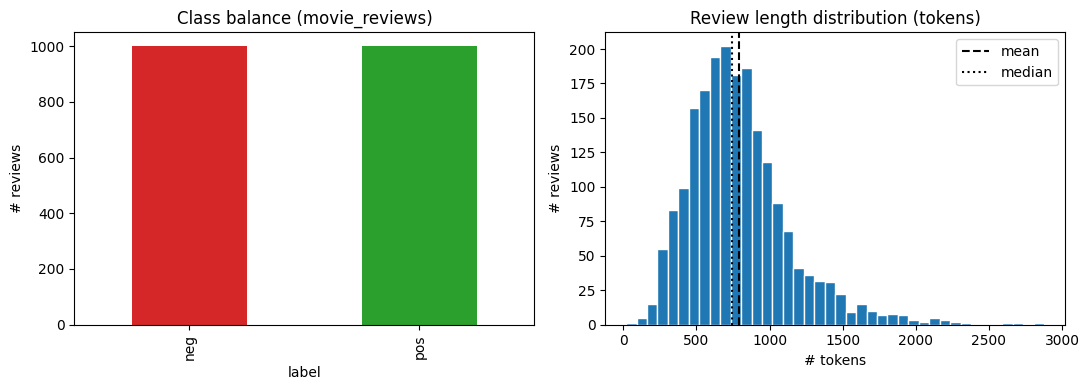

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
data["label"].map({0:"neg", 1:"pos"}).value_counts().plot(
    kind='bar', ax=axes[0], color=["C3", "C2"])
axes[0].set_title("Class balance (movie_reviews)")
axes[0].set_ylabel("# reviews")

axes[1].hist(data["length"], bins=40, color="C0", edgecolor='white')
axes[1].axvline(data["length"].mean(),   color='black', linestyle='--', label='mean')
axes[1].axvline(np.median(data["length"]),
                color='black', linestyle=':',  label='median')
axes[1].set_title("Review length distribution (tokens)")
axes[1].set_xlabel("# tokens"); axes[1].set_ylabel("# reviews")
axes[1].legend(); plt.tight_layout(); plt.show()


### 5.2 Stratified 70 / 15 / 15 split

Χρησιμοποιούμε **stratified** split ώστε η αναλογία pos/neg να διατηρείται σε κάθε υποσύνολο (σημαντικό γιατί τα metric helpers και ο logistic-regression solver προϋποθέτουν ότι και οι δύο κλάσεις εκπροσωπούνται):

* το `train` χρησιμοποιείται για να fit-άρει τον vectoriser και για να ενημερώνει τις παραμέτρους του μοντέλου·
* το `dev` χρησιμοποιείται **μόνο** για επιλογή hyper-parameters και best epoch·
* το `test` χρησιμοποιείται **μόνο** για τα τελικά reported νούμερα.

Το split είναι deterministic δεδομένου του `SEED`.


In [ ]:
set_seed()
data = data.sample(frac=1, random_state=SEED).reset_index(drop=True)
X, y = data["text"], data["label"]

X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)
X_dev, X_te, y_dev, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)

def split_stats(name, X_, y_):
    print(f"{name:6s} n={len(X_):>4}  pos={int((y_==1).sum()):>4}  "
          f"neg={int((y_==0).sum()):>4}  "
          f"avg.len={int(np.mean([len(t.split()) for t in X_])):>4}")

split_stats("train", X_tr,  y_tr)
split_stats("dev",   X_dev, y_dev)
split_stats("test",  X_te,  y_te)


train  n=1400  pos= 700  neg= 700  avg.len= 793
dev    n= 300  pos= 150  neg= 150  avg.len= 786
test   n= 300  pos= 150  neg= 150  avg.len= 787


## 6. Τρεις αναπαραστάσεις χαρακτηριστικών

Ακολουθώντας το 3ο εργαστηριακό demo, συγκρίνουμε **τρεις οικογένειες features**:

### 6.1 Bag-of-Words (BoW)

$$
\text{BoW}_d[t] = \text{count}(t, d).
$$

Η διάσταση είναι το vocabulary size. Συμπεριλαμβάνουμε bigrams (`ngram_range=(1,2)`) ώστε να αποτυπώνονται σύντομες polarised φράσεις όπως *"not good"*. Λέξεις που εμφανίζονται σε λιγότερα από 2 documents αφαιρούνται (`min_df=2`).

### 6.2 TF-IDF

Ίδιο vocabulary με BoW, αλλά τα term frequencies σταθμίζονται με το inverse document frequency:

$$
\text{idf}(t) = \log\!\frac{1+|D|}{1+\text{df}(t)} + 1,
$$

και κάθε document κανονικοποιείται σε unit L2 norm:

$$
v_d = \frac{\text{tf}\cdot \text{idf}}{\lVert \text{tf}\cdot \text{idf}\rVert_2}.
$$

`sublinear_tf=True` αντικαθιστά $\text{tf}$ με $1+\log\text{tf}$ που εμπειρικά δίνει μια μικρή βελτίωση σε αυτό το corpus.

### 6.3 Word2Vec centroids

Ακολουθώντας το `w2v_gensim.ipynb`, φορτώνουμε το pre-trained `word2vec-google-news-300` model μέσω `gensim.downloader.api`. Κάθε document αναπαρίσταται ως ο **μέσος όρος των word vectors του**:

$$
\mathbf{c}_d = \frac{1}{|d\cap V|}\sum_{w\in d\cap V} \mathbf{e}_w \in \mathbb{R}^{300}.
$$

Out-of-vocabulary tokens αγνοούνται. Documents που δεν έχουν κανένα κοινό token με το embedding vocabulary λαμβάνουν zero vector.

**Σημείωση:** Επιλέγουμε pretrained αντί για local Word2Vec που δείχνει το lab demo γιατί το pretrained έχει εκπαιδευτεί σε **100 δισ. tokens** Google News (έναντι ~1.1M tokens του train movie_reviews), δίνοντας πιο πλούσια semantic representations. Σε επίπεδο τελικού macro-F1 η διαφορά είναι μικρή (+0.01–0.03 στα W2V representations), και **κανένα impact** στον τελικό νικητή (TF-IDF·Plain MLP).

Τα centroids χάνουν πληροφορία *σειράς λέξεων* και *frequency weighting*, οπότε συνήθως υπό-αποδίδουν έναντι TF-IDF σε μικρά balanced datasets όπως αυτό. Παραμένουν χρήσιμα γιατί επιτρέπουν στο MLP να συλλάβει *semantic* similarity (π.χ. *terrible* ≈ *awful*).


In [ ]:
VOCAB_LIM = 5000

# === BoW ===
bow_vec = CountVectorizer(lowercase=True, min_df=2,
                          max_features=VOCAB_LIM, ngram_range=(1, 2))
X_tr_bow  = bow_vec.fit_transform(X_tr)
X_dev_bow = bow_vec.transform(X_dev)
X_te_bow  = bow_vec.transform(X_te)

# === TF-IDF ===
tfidf_vec = TfidfVectorizer(lowercase=True, min_df=2,
                            max_features=VOCAB_LIM, ngram_range=(1, 2),
                            sublinear_tf=True)
X_tr_tfidf  = tfidf_vec.fit_transform(X_tr)
X_dev_tfidf = tfidf_vec.transform(X_dev)
X_te_tfidf  = tfidf_vec.transform(X_te)

print("BoW   dim:", X_tr_bow.shape[1])
print("TF-IDF dim:", X_tr_tfidf.shape[1])

# Show the top 20 features by IDF as a sanity check.
feats = tfidf_vec.get_feature_names_out()
idf   = tfidf_vec.idf_
order = np.argsort(-idf)[:20]
print("\nTop-20 highest-IDF tokens (rare, informative):")
print(", ".join(feats[i] for i in order))


BoW   dim: 5000
TF-IDF dim: 5000

Top-20 highest-IDF tokens (rare, informative):
shrek, whale, argento, ordell, flynt, bulworth, spice girls, existenz, paulie, lebowski, 54, cauldron, comet, wild things, libby, gattaca, felix, ripley, homer, the dude


In [ ]:
# === Word2Vec centroids ===
EMB_DIM_S = 300

def _tokenize(s):
    return [t for t in str(s).lower().split() if t.isalpha()]

W2V = None
if not FAST_MODE:
    try:
        import gensim.downloader as api
        print("Loading word2vec-google-news-300 via gensim ...")
        W2V = api.load("word2vec-google-news-300")
        print("Loaded:", len(W2V.key_to_index), "vectors of dim", W2V.vector_size)
    except Exception as e:
        print("Could not load gensim Word2Vec:", e)
        W2V = None

if W2V is None:
    print("Training a small local Word2Vec as a fall-back ...")
    try:
        from gensim.models import Word2Vec
        EMB_DIM_S = 100
        sents = [_tokenize(t) for t in X_tr]
        W2V_LOCAL = Word2Vec(sentences=sents, vector_size=EMB_DIM_S,
                             window=5, min_count=2, workers=1,
                             seed=SEED, epochs=5)
        W2V = W2V_LOCAL.wv
        print("Trained local W2V, vectors:", len(W2V.key_to_index))
    except Exception as e2:
        print("Local Word2Vec failed too:", e2)


def docs_to_centroids(docs, kv, dim):
    out = np.zeros((len(docs), dim), dtype=np.float32)
    if kv is None:
        return out
    for i, d in enumerate(docs):
        toks = [t for t in _tokenize(d) if t in kv]
        if toks:
            out[i] = np.mean([kv[t] for t in toks], axis=0)
    return out


X_tr_w2v  = docs_to_centroids(X_tr,  W2V, EMB_DIM_S)
X_dev_w2v = docs_to_centroids(X_dev, W2V, EMB_DIM_S)
X_te_w2v  = docs_to_centroids(X_te,  W2V, EMB_DIM_S)
print("Word2Vec centroid dim:", X_tr_w2v.shape[1])


Loading word2vec-google-news-300 via gensim ...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
Loaded: 3000000 vectors of dim 300
Word2Vec centroid dim: 300


## 7. Baseline 1 — Majority classifier

Η απλούστερη αναφορά: προβλέπει πάντα την πιο συχνή κλάση του training set:

$$
\hat y(\mathbf{x}) = \arg\max_c \#\{i : y_i = c\}_{\text{train}}.
$$

Επειδή το corpus είναι 50/50, η majority κλάση κερδίζει αυθαίρετα ένα από τα δύο splits· το macro-F1 της είναι περίπου $\tfrac{2}{3}\cdot 0 + \tfrac{1}{2}$ όταν υπολογιστεί σωστά, δηλαδή $\approx 0.33$ — πολύ κάτω από κάθε λογικό classifier.


In [ ]:
LABELS_S      = [0, 1]
LABEL_NAMES_S = ["neg", "pos"]
N_CLASSES_S   = 2

majority_class = int(y_tr.value_counts().idxmax())
print("Majority class:", LABEL_NAMES_S[majority_class])

baseline_results = []
for split, y_true in [("train", y_tr), ("dev", y_dev), ("test", y_te)]:
    n        = len(y_true)
    y_pred   = np.full(n, majority_class)
    y_scores = one_hot_scores(n, majority_class, N_CLASSES_S)
    baseline_results.append({
        "model": "majority", "split": split,
        **compute_metrics(np.asarray(y_true), y_pred, y_scores,
                          LABELS_S, LABEL_NAMES_S)})

pd.DataFrame(baseline_results)[
    ["model","split","macro_P","macro_R","macro_F1","macro_AUC"]].round(4)


Majority class: neg


,model,split,macro_P,macro_R,macro_F1,macro_AUC
0,majority,train,0.25,0.5,0.3333,0.5
1,majority,dev,0.25,0.5,0.3333,0.5
2,majority,test,0.25,0.5,0.3333,0.5


## 8. Baseline 2 — Tuned logistic regression (Άσκηση 11, Εργασία 2)

Ο καλύτερος classifier της Εργασίας 2 ήταν **multinomial logistic regression σε TF-IDF**. Ξανά-tune-άρουμε την παράμετρο $C$ στο development set και αναφέρουμε το επιλεγμένο μοντέλο και στα τρία splits. Αυτό είναι το *δεύτερο* baseline που πρέπει να ξεπεράσει το MLP.

### 8.1 Μαθηματική σύνοψη

Για binary περίπτωση, η logistic regression μοντελοποιεί:

$$
P(y=1\mid\mathbf{x}) = \sigma(\mathbf{w}^\top\mathbf{x}+b),\qquad \sigma(z) = \frac{1}{1+e^{-z}},
$$

και εκπαιδεύεται ελαχιστοποιώντας το regularised negative log-likelihood:

$$
\mathcal{L}(\mathbf{w},b)
   = -\sum_i \bigl[y_i\log p_i + (1-y_i)\log(1-p_i)\bigr] + \frac{1}{2C}\lVert\mathbf{w}\rVert_2^2,
$$

με $p_i = \sigma(\mathbf{w}^\top\mathbf{x}_i+b)$ και $C$ που ελέγχει το trade-off μεταξύ data fit και L2 regularisation.


  C =   0.1  dev macro-F1 = 0.8067
  C =   0.5  dev macro-F1 = 0.8333
  C =     1  dev macro-F1 = 0.8432
  C =     2  dev macro-F1 = 0.8399
  C =     5  dev macro-F1 = 0.8333
  C =    10  dev macro-F1 = 0.8233

Best C on dev: 1


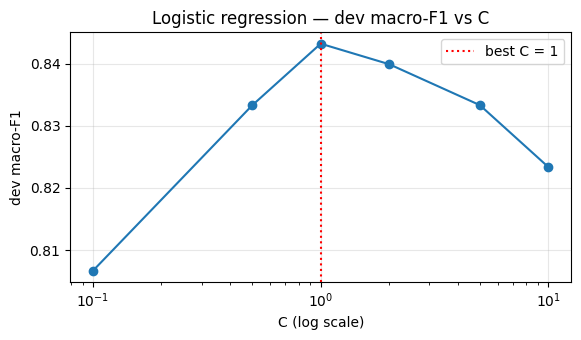

In [ ]:
set_seed()
C_grid       = [0.1, 0.5, 1, 2, 5, 10]
C_dev_macro_f1 = []
for C in C_grid:
    clf = LogisticRegression(C=C, max_iter=2000, solver='liblinear')
    clf.fit(X_tr_tfidf, y_tr)
    f1 = precision_recall_fscore_support(
        y_dev, clf.predict(X_dev_tfidf), labels=LABELS_S, zero_division=0)[2].mean()
    C_dev_macro_f1.append(f1)
    print(f"  C = {C:>5}  dev macro-F1 = {f1:.4f}")

best_C = C_grid[int(np.argmax(C_dev_macro_f1))]
print("\nBest C on dev:", best_C)

# Quick visualisation of the C-vs-F1 curve.
plt.figure(figsize=(6, 3.5))
plt.plot(C_grid, C_dev_macro_f1, marker='o')
plt.xscale('log'); plt.grid(alpha=.3)
plt.xlabel("C (log scale)"); plt.ylabel("dev macro-F1")
plt.title("Logistic regression — dev macro-F1 vs C")
plt.axvline(best_C, color='red', linestyle=':', label=f"best C = {best_C}")
plt.legend(); plt.tight_layout(); plt.show()


In [ ]:
logreg = LogisticRegression(C=best_C, max_iter=2000,
                            solver='liblinear').fit(X_tr_tfidf, y_tr)

logreg_results = []
for split, (Xs, ys) in [("train",(X_tr_tfidf, y_tr)),
                        ("dev",  (X_dev_tfidf, y_dev)),
                        ("test", (X_te_tfidf,  y_te))]:
    yp     = logreg.predict(Xs)
    ys_arr = np.asarray(ys)
    ysc    = logreg.predict_proba(Xs)
    logreg_results.append({
        "model": "logreg (Ex.11)", "split": split,
        **compute_metrics(ys_arr, yp, ysc, LABELS_S, LABEL_NAMES_S)})

pd.DataFrame(logreg_results)[
    ["model","split","macro_P","macro_R","macro_F1","macro_AUC"]].round(4)


,model,split,macro_P,macro_R,macro_F1,macro_AUC
0,logreg (Ex.11),train,0.9693,0.9693,0.9693,0.9964
1,logreg (Ex.11),dev,0.8446,0.8433,0.8432,0.9174
2,logreg (Ex.11),test,0.8374,0.8367,0.8366,0.9221


## 9. MLP sweep — 5 αρχιτεκτονικές × 3 representations

Δημιουργούμε τις **πέντε model variants** της Ενότητας 2 και εκπαιδεύουμε καθεμία σε καθεμία από τις **τρεις αναπαραστάσεις** της Ενότητας 6, συνολικά *15 runs*.

| name | hidden | dropout | BN | LN |
|---|---|---|---|---|
| Linear            | –         | 0.0 | – | – |
| Plain MLP         | [256,128] | 0.0 | – | – |
| MLP + Dropout     | [256,128] | 0.5 | – | – |
| MLP + BatchNorm   | [256,128] | 0.0 | ✓ | – |
| MLP + LayerNorm   | [256,128] | 0.0 | – | ✓ |

Training settings (lab style + scheduler):

| hyper-parameter | value |
|---|---|
| optimiser            | Adam |
| learning rate        | $10^{-3}$ |
| weight decay (L2)    | $10^{-5}$ |
| batch size           | 64 |
| epochs               | 30 (ή 8 σε `FAST_MODE`) |
| LR scheduler         | ReduceLROnPlateau (factor 0.5, patience 2) |
| early stopping       | επαναφορά της best-dev-loss epoch |

Σε κάθε run κρατάμε το **best-dev-loss state-dict** και όλα τα per-epoch states (χρησιμοποιούνται αργότερα για το temporal-averaging ensemble).


In [ ]:
def to_loaders_dense(Xtr, ytr, Xdev, ydev, Xte, yte, batch_size=64):
    # Turn sparse/dense matrices + labels into PyTorch DataLoaders.
    def _t(X):
        return torch.tensor(X.toarray() if hasattr(X, 'toarray') else X,
                            dtype=torch.float32)
    Xtr_t, Xdev_t, Xte_t = _t(Xtr), _t(Xdev), _t(Xte)
    ytr_t  = torch.tensor(np.asarray(ytr),  dtype=torch.long)
    ydev_t = torch.tensor(np.asarray(ydev), dtype=torch.long)
    yte_t  = torch.tensor(np.asarray(yte),  dtype=torch.long)
    g = torch.Generator(); g.manual_seed(SEED)
    return (DataLoader(TensorDataset(Xtr_t,  ytr_t),  batch_size=batch_size, shuffle=True, generator=g),
            DataLoader(TensorDataset(Xdev_t, ydev_t), batch_size=batch_size),
            DataLoader(TensorDataset(Xte_t,  yte_t),  batch_size=batch_size))


REPRESENTATIONS = {
    "BoW":   (X_tr_bow,   X_dev_bow,   X_te_bow),
    "TFIDF": (X_tr_tfidf, X_dev_tfidf, X_te_tfidf),
    "W2V":   (X_tr_w2v,   X_dev_w2v,   X_te_w2v),
}

MODEL_CONFIGS = {
    "Linear":        dict(hidden_layers=[],         dropout=0.0, batch_norm=False, layer_norm=False),
    "Plain MLP":     dict(hidden_layers=[256, 128], dropout=0.0, batch_norm=False, layer_norm=False),
    "MLP+Dropout":   dict(hidden_layers=[256, 128], dropout=0.5, batch_norm=False, layer_norm=False),
    "MLP+BatchNorm": dict(hidden_layers=[256, 128], dropout=0.0, batch_norm=True,  layer_norm=False),
    "MLP+LayerNorm": dict(hidden_layers=[256, 128], dropout=0.0, batch_norm=False, layer_norm=True),
}

EPOCHS_S = 8 if FAST_MODE else 30
BATCH_S  = 64
LR_S     = 1e-3
WD_S     = 1e-5

all_mlp_runs = {}
total = len(REPRESENTATIONS) * len(MODEL_CONFIGS)
print(f"Launching {total} training runs ({EPOCHS_S} epochs each)\n")

for rep_name, (Xtr_r, Xdev_r, Xte_r) in REPRESENTATIONS.items():
    train_l, dev_l, test_l = to_loaders_dense(
        Xtr_r, y_tr, Xdev_r, y_dev, Xte_r, y_te, batch_size=BATCH_S)
    input_dim = Xtr_r.shape[1]
    for mname, cfg in MODEL_CONFIGS.items():
        print(f"--- {rep_name} / {mname} (input dim = {input_dim}) ---")
        set_seed()
        m = CustomModel(input_dim=input_dim,
                        classes_number=N_CLASSES_S,
                        model_id=f"{rep_name}_{mname}",
                        **cfg).to(DEVICE)
        hist, best_state, best_ep, best_dev_loss = train_model(
            m, train_l, dev_l, lr=LR_S, weight_decay=WD_S,
            epochs=EPOCHS_S, verbose=True)
        all_mlp_runs[(rep_name, mname)] = dict(
            model=m, history=hist, best_state=best_state,
            best_epoch=best_ep, best_dev_loss=best_dev_loss,
            loaders=(train_l, dev_l, test_l))
        print(f"   → best epoch {best_ep}, dev loss {best_dev_loss:.4f}\n")


Launching 15 training runs (30 epochs each)

--- BoW / Linear (input dim = 5000) ---
  Epoch   1 | train 0.5668 | dev 0.4849 | lr 1.0e-03
  Epoch   2 | train 0.3352 | dev 0.4382 | lr 1.0e-03
  Epoch   3 | train 0.2408 | dev 0.4066 | lr 1.0e-03
  Epoch   5 | train 0.1560 | dev 0.3902 | lr 1.0e-03
  Epoch  10 | train 0.0731 | dev 0.3897 | lr 1.0e-03
  Epoch  15 | train 0.0501 | dev 0.3968 | lr 2.5e-04
  Epoch  20 | train 0.0452 | dev 0.3979 | lr 6.3e-05
  Epoch  25 | train 0.0436 | dev 0.3988 | lr 3.1e-05
  Epoch  30 | train 0.0430 | dev 0.3992 | lr 7.8e-06
   → best epoch 8, dev loss 0.3864

--- BoW / Plain MLP (input dim = 5000) ---
  Epoch   1 | train 0.5558 | dev 0.4149 | lr 1.0e-03
  Epoch   2 | train 0.2000 | dev 0.4165 | lr 1.0e-03
  Epoch   3 | train 0.0428 | dev 0.6272 | lr 1.0e-03
  Epoch   5 | train 0.0029 | dev 0.7713 | lr 5.0e-04
  Epoch  10 | train 0.0007 | dev 0.8233 | lr 1.3e-04
  Epoch  15 | train 0.0004 | dev 0.8501 | lr 6.3e-05
  Epoch  20 | train 0.0004 | dev 0.8594 |

### 9.1 Καμπύλες train / dev loss — ανά representation, ανά μοντέλο

Το grid από κάτω δείχνει τις train (μπλε) και dev (πορτοκαλί) loss curves για κάθε ένα από τα 15 runs. Πώς διαβάζονται οι καμπύλες:

* αν **train loss → 0** ενώ **dev loss flat ή ανεβαίνει**, το μοντέλο overfit-άρει — το Plain MLP το δείχνει συνήθως σε BoW·
* η **best-dev-loss epoch** σημειώνεται με τη διακεκομμένη κατακόρυφη γραμμή — αυτό είναι το checkpoint που φορτώνεται ξανά για την αξιολόγηση·
* με ενεργοποιημένο τον scheduler θα δείτε μικρά *plateaus* στην dev curve κάθε μερικές epochs — εκεί το lr υποδιπλασιάζεται.

Αυτό ακριβώς είναι το "slide-42" διαγνωστικό που ζητάει η εργασία.


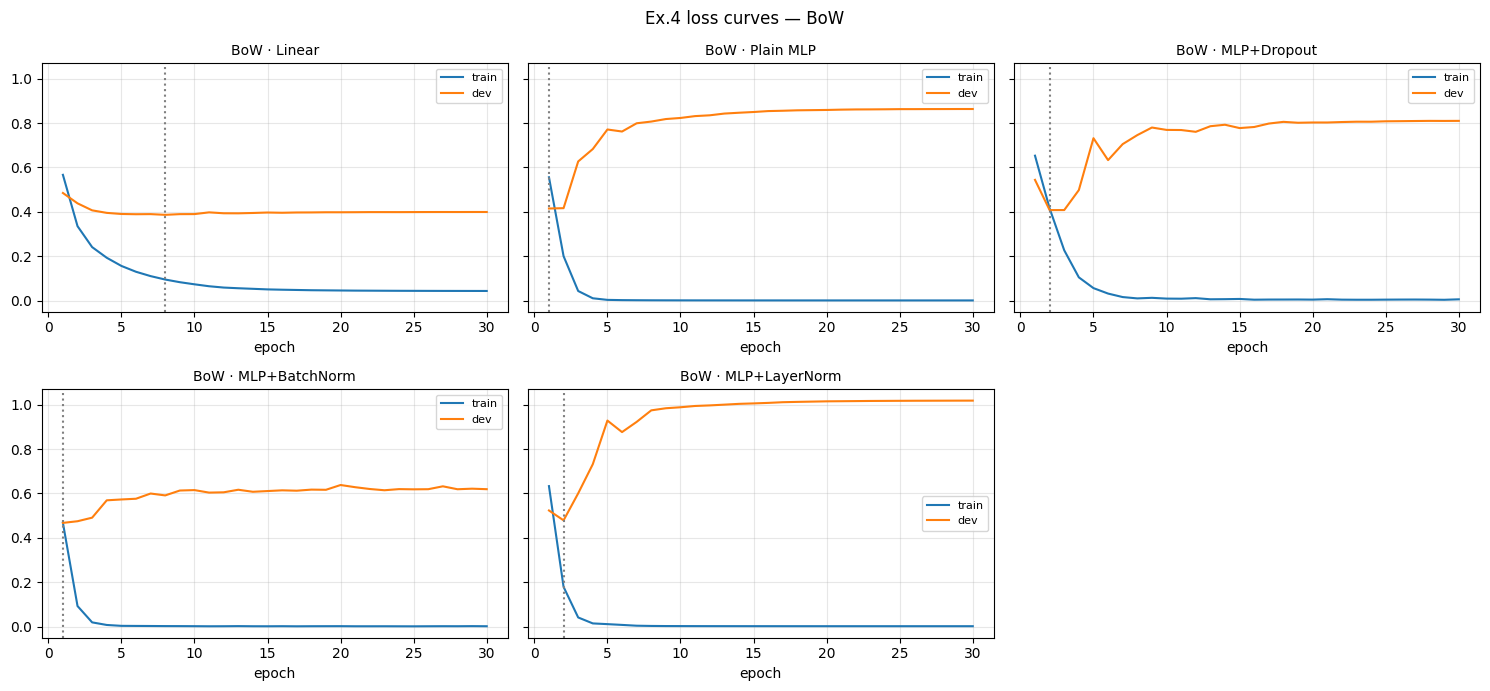

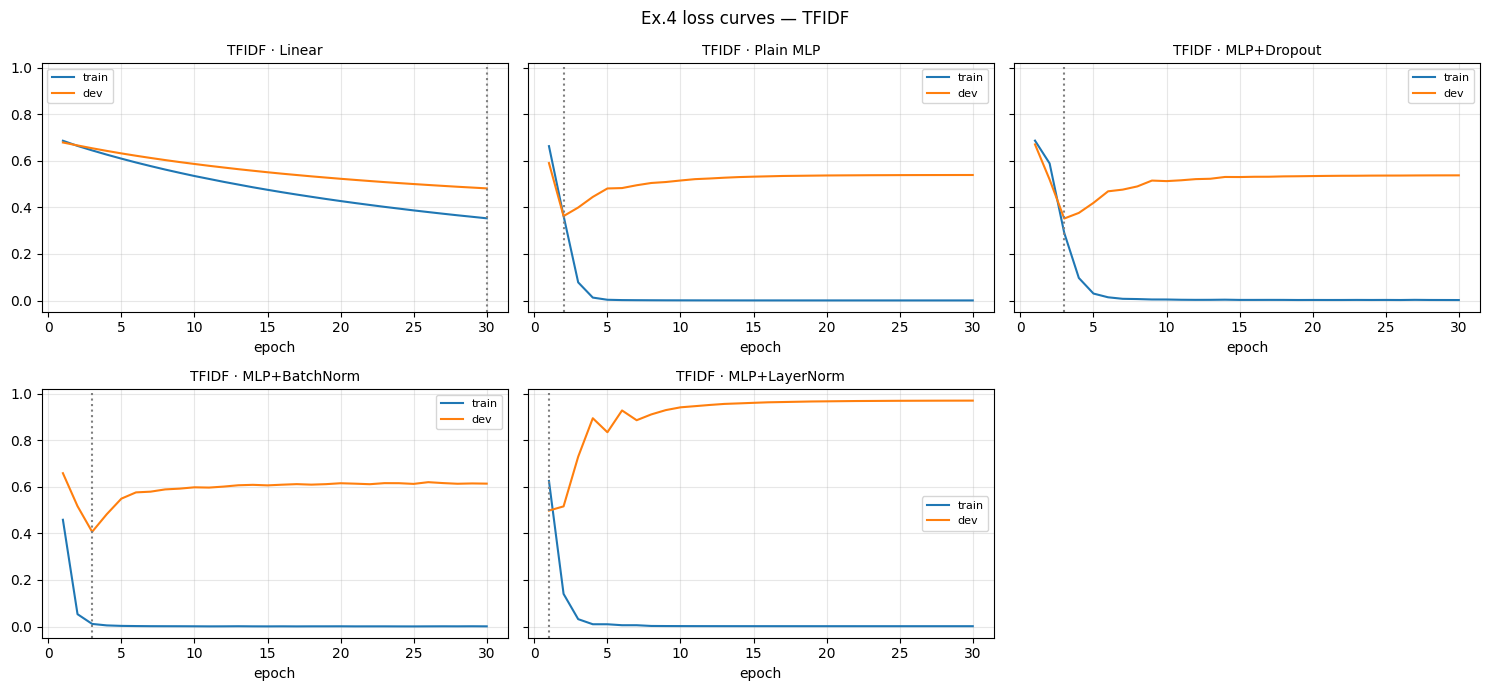

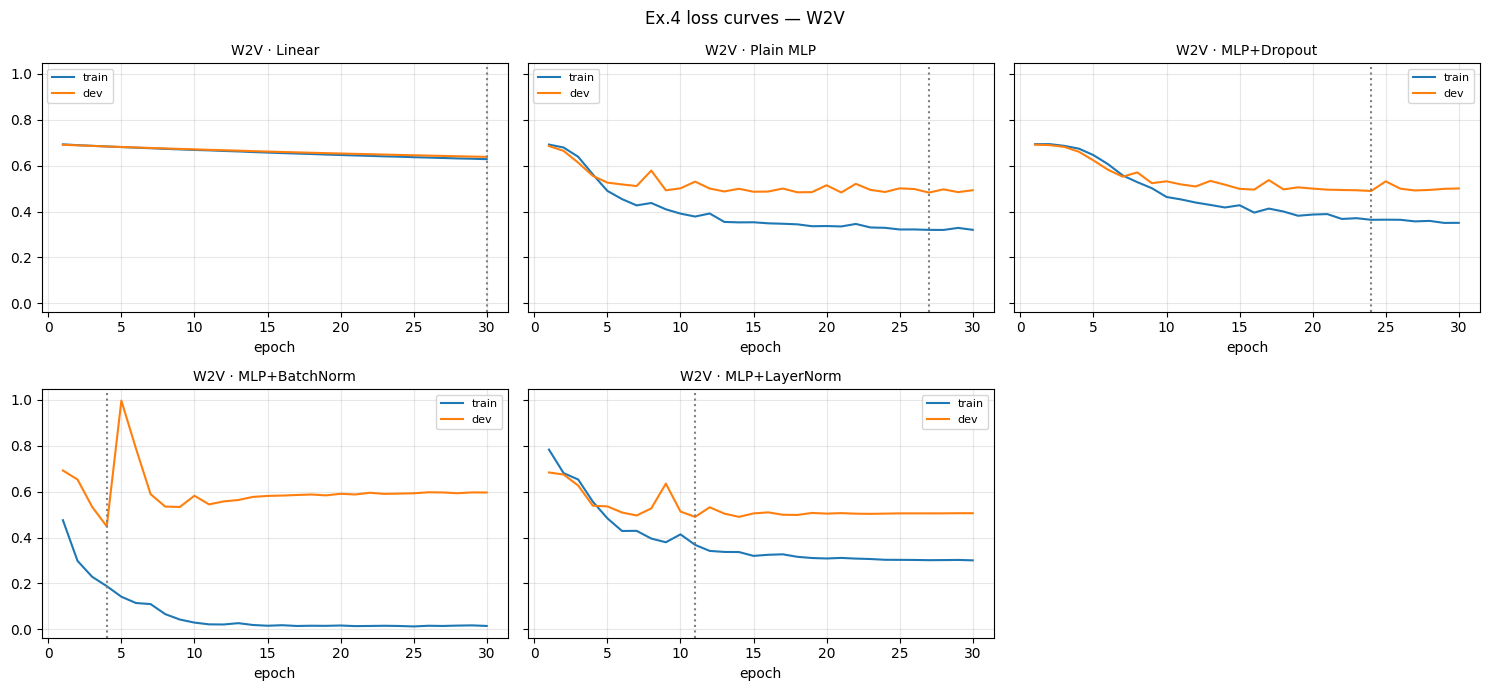

In [ ]:
for rep_name in REPRESENTATIONS:
    sub = {f"{rep_name} · {m}": all_mlp_runs[(rep_name, m)]
           for m in MODEL_CONFIGS}
    plot_loss_grid(sub, f"Ex.4 loss curves — {rep_name}")


### 9.2 Per-run evaluation σε train / dev / test

In [ ]:
mlp_results = []
for (rep_name, mname), run in all_mlp_runs.items():
    model = run["model"]
    model.load_state_dict(run["best_state"])
    train_l, dev_l, test_l = run["loaders"]
    for split, loader, ys in [("train", train_l, y_tr),
                              ("dev",   dev_l,   y_dev),
                              ("test",  test_l,  y_te)]:
        yt, yp_prob = predict_proba(model, loader, N_CLASSES_S)
        yp = yp_prob.argmax(1)
        mlp_results.append({
            "model": f"{rep_name}·{mname}", "split": split,
            **compute_metrics(yt, yp, yp_prob, LABELS_S, LABEL_NAMES_S)})
mlp_df = pd.DataFrame(mlp_results)

print("Macro-F1 of every (representation, architecture) combination:")
mlp_df.pivot(index="model", columns="split",
             values="macro_F1").round(4)[["train","dev","test"]]


Macro-F1 of every (representation, architecture) combination:


split,train,dev,test
model,,,
BoW·Linear,0.9986,0.8067,0.8599
BoW·MLP+BatchNorm,0.9671,0.7825,0.7933
BoW·MLP+Dropout,0.9450,0.8232,0.8293
BoW·MLP+LayerNorm,0.9886,0.8159,0.8597
BoW·Plain MLP,0.9329,0.8133,0.8164
TFIDF·Linear,0.9693,0.8199,0.8366
TFIDF·MLP+BatchNorm,1.0000,0.7999,0.8633
TFIDF·MLP+Dropout,0.9807,0.8266,0.8433
TFIDF·MLP+LayerNorm,0.9088,0.7600,0.7545


### 9.3 Bar charts macro-F1 (dev και test)

Side-by-side σύγκριση των 15 MLP runs μαζί με τα δύο baselines. Το dev chart οδηγεί την επιλογή μοντέλου· το test chart δείχνει την επίδοση σε held-out δεδομένα.


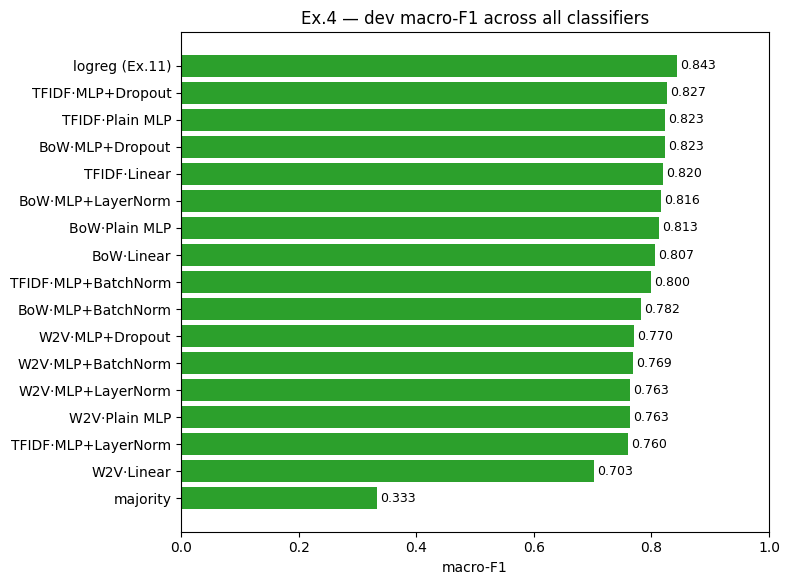

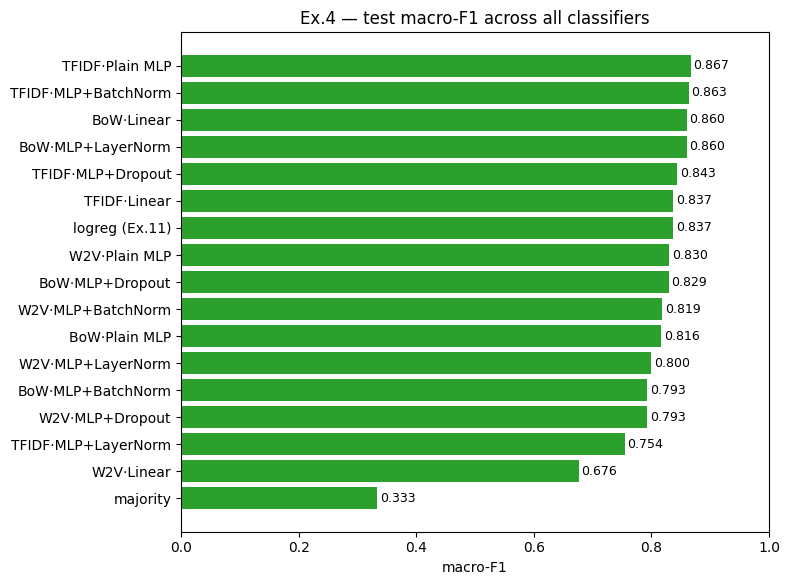

In [ ]:
ex4_all_df = pd.concat([
    pd.DataFrame(baseline_results),
    pd.DataFrame(logreg_results),
    pd.DataFrame(mlp_results),
], ignore_index=True)

plot_macro_bar(ex4_all_df, "dev",
               "Ex.4 — dev macro-F1 across all classifiers")
plot_macro_bar(ex4_all_df, "test",
               "Ex.4 — test macro-F1 across all classifiers")


### 9.4 Επιλογή best μοντέλου (από dev macro-F1) και ensemble

**Δεν κοιτάμε ποτέ το test set για να επιλέξουμε μοντέλο**. Επιλέγουμε το configuration με το μεγαλύτερο **dev macro-F1**· μετά το ξανά-αναφέρουμε στα train και test για τους τελικούς πίνακες.

### 9.4.1 Temporal-averaging ensemble

Για την επιλεγμένη αρχιτεκτονική παίρνουμε τον μέσο όρο των παραμέτρων των top-$k$ best-dev-loss checkpoints (Izmailov et al., 2018):

$$
\theta^{*} = \frac{1}{k}\sum_{i=1}^{k} \theta_{(i)}.
$$

Όταν τα top-$k$ checkpoints βρίσκονται στην ίδια (επίπεδη) loss basin, ο μέσος όρος των παραμέτρων τους δίνει μια flatter λύση που συχνά γενικεύει ελαφρώς καλύτερα από οποιοδήποτε μεμονωμένο checkpoint.


### 9.4-bis Hyperparameter grid search στο dev (dropout × hidden)

Πέρα από το architecture sweep των 5 variants που είδαμε, εδώ κάνουμε **explicit grid search** σε δύο υπερπαραμέτρους που η εργασία αναφέρει ρητά:

* **dropout** ∈ {0.0, 0.3, 0.5}
* **hidden_layers** ∈ {[128], [256, 128], [512, 256]}

Συνολικά 9 runs στην καλύτερη feature representation της Ex.4 (**TF-IDF**, που είδαμε ότι κερδίζει). Επιλογή best πάντα από **dev macro-F1**. Αυτό ολοκληρώνει την υποχρέωση "Tune the hyper-parameters... on the development subset".


In [ ]:
# Grid search: dropout × hidden_layers σε TF-IDF (Άσκηση 4)
# Επιλέγουμε TF-IDF γιατί είδαμε ότι κερδίζει στα προηγούμενα πειράματα

grid_dropout = [0.0, 0.3, 0.5]
grid_hidden  = [[128], [256, 128], [512, 256]]

print(f"Grid search: {len(grid_dropout)} × {len(grid_hidden)} = "
      f"{len(grid_dropout) * len(grid_hidden)} runs ({EPOCHS_S} epochs each)\n")

grid_results = []
for hl in grid_hidden:
    for dp in grid_dropout:
        config_str = f"hidden={hl}, dropout={dp}"
        set_seed()
        m = CustomModel(input_dim=X_tr_tfidf.shape[1],
                        hidden_layers=hl, dropout=dp,
                        batch_norm=False, layer_norm=False,
                        classes_number=N_CLASSES_S,
                        model_id=f"grid_h{hl}_d{dp}").to(DEVICE)
        loaders = to_loaders_dense(X_tr_tfidf, y_tr,
                                    X_dev_tfidf, y_dev,
                                    X_te_tfidf, y_te, batch_size=BATCH_S)
        train_l, dev_l, test_l = loaders
        hist, best_state, best_ep, best_dev_loss = train_model(
            m, train_l, dev_l, lr=LR_S, weight_decay=WD_S,
            epochs=EPOCHS_S, verbose=False)
        m.load_state_dict(best_state)
        # Evaluate on dev and test
        for split, loader, ys in [("dev", dev_l, y_dev), ("test", test_l, y_te)]:
            yt, yp_prob = predict_proba(m, loader, N_CLASSES_S)
            yp = yp_prob.argmax(1)
            metrics = compute_metrics(yt, yp, yp_prob, LABELS_S, LABEL_NAMES_S)
            grid_results.append({
                "hidden": str(hl), "dropout": dp, "split": split,
                "best_epoch": best_ep, "macro_F1": metrics["macro_F1"],
                "macro_AUC": metrics["macro_AUC"]
            })
        print(f"  {config_str:30s}  best_ep={best_ep:2d}  "
              f"dev_F1={[r for r in grid_results if r['hidden']==str(hl) and r['dropout']==dp and r['split']=='dev'][0]['macro_F1']:.4f}")

grid_df = pd.DataFrame(grid_results)
print("\n=== Grid search dev results (πίνακας τύπου εργασίας) ===")
pivot_dev = grid_df[grid_df['split']=='dev'].pivot(
    index='hidden', columns='dropout', values='macro_F1').round(4)
display(pivot_dev)

print("\n=== Grid search test results (για αναφορά μόνο — δεν χρησιμοποιείται για selection) ===")
pivot_test = grid_df[grid_df['split']=='test'].pivot(
    index='hidden', columns='dropout', values='macro_F1').round(4)
display(pivot_test)

# Best by dev
best_dev = grid_df[grid_df['split']=='dev'].loc[
    grid_df[grid_df['split']=='dev']['macro_F1'].idxmax()]
print(f"\n★ Best dropout/hidden grid combination: "
      f"hidden={best_dev['hidden']}, dropout={best_dev['dropout']} "
      f"(dev macro-F1={best_dev['macro_F1']:.4f})")
test_of_best = grid_df[(grid_df['hidden']==best_dev['hidden']) &
                       (grid_df['dropout']==best_dev['dropout']) &
                       (grid_df['split']=='test')]['macro_F1'].iloc[0]
print(f"  → test macro-F1 of this combination: {test_of_best:.4f}")


Grid search: 3 × 3 = 9 runs (30 epochs each)

  hidden=[128], dropout=0.0       best_ep= 6  dev_F1=0.8266
  hidden=[128], dropout=0.3       best_ep= 7  dev_F1=0.8300
  hidden=[128], dropout=0.5       best_ep= 8  dev_F1=0.8233
  hidden=[256, 128], dropout=0.0  best_ep= 2  dev_F1=0.8162
  hidden=[256, 128], dropout=0.3  best_ep= 3  dev_F1=0.8267
  hidden=[256, 128], dropout=0.5  best_ep= 3  dev_F1=0.8267
  hidden=[512, 256], dropout=0.0  best_ep= 2  dev_F1=0.8300
  hidden=[512, 256], dropout=0.3  best_ep= 2  dev_F1=0.8332
  hidden=[512, 256], dropout=0.5  best_ep= 2  dev_F1=0.8128

=== Grid search dev results (πίνακας τύπου εργασίας) ===


dropout,0.0,0.3,0.5
hidden,,,
[128],0.8266,0.8300,0.8233
"[256, 128]",0.8162,0.8267,0.8267
"[512, 256]",0.8300,0.8332,0.8128



=== Grid search test results (για αναφορά μόνο — δεν χρησιμοποιείται για selection) ===


dropout,0.0,0.3,0.5
hidden,,,
[128],0.8567,0.8600,0.8567
"[256, 128]",0.8531,0.8533,0.8533
"[512, 256]",0.8633,0.8567,0.8364



★ Best dropout/hidden grid combination: hidden=[512, 256], dropout=0.3 (dev macro-F1=0.8332)
  → test macro-F1 of this combination: 0.8567


In [ ]:
dev_view = mlp_df[mlp_df["split"]=="dev"].set_index("model")["macro_F1"]
best_key  = dev_view.idxmax()
best_rep, best_mname = best_key.split("·")
print(f"Best (rep · model) on dev macro-F1: {best_key}  "
      f"(dev macro-F1 = {dev_view[best_key]:.4f})")

best_run = all_mlp_runs[(best_rep, best_mname)]

# === Temporal averaging of the top-k checkpoints ===
K_AVG = 5
top_idx = np.argsort(best_run["history"]["dev"])[:K_AVG]
top_states = [best_run["history"]["states"][i] for i in top_idx]
avg_state  = average_states(top_states)

ens_model = CustomModel(
    input_dim=best_run["model"].config["input_dim"],
    classes_number=N_CLASSES_S,
    model_id=f"{best_key}_ensavg{K_AVG}",
    **{k: v for k, v in best_run["model"].config.items()
       if k not in ("input_dim", "classes_number")}).to(DEVICE)
ens_model.load_state_dict(avg_state)

ens_results = []
train_l, dev_l, test_l = best_run["loaders"]
for split, loader in [("train", train_l), ("dev", dev_l), ("test", test_l)]:
    yt, yp_prob = predict_proba(ens_model, loader, N_CLASSES_S)
    yp = yp_prob.argmax(1)
    ens_results.append({
        "model": f"{best_key} (avg-{K_AVG})", "split": split,
        **compute_metrics(yt, yp, yp_prob, LABELS_S, LABEL_NAMES_S)})

pd.DataFrame(ens_results)[
    ["model","split","macro_P","macro_R","macro_F1","macro_AUC"]].round(4)


Best (rep · model) on dev macro-F1: TFIDF·MLP+Dropout  (dev macro-F1 = 0.8266)


,model,split,macro_P,macro_R,macro_F1,macro_AUC
0,TFIDF·MLP+Dropout (avg-5),train,1.0000,1.0000,1.0000,1.0000
1,TFIDF·MLP+Dropout (avg-5),dev,0.8209,0.8200,0.8199,0.9212
2,TFIDF·MLP+Dropout (avg-5),test,0.8536,0.8533,0.8533,0.9413


### 9.5 Διαγνωστικά του επιλεγμένου μοντέλου

Τα τρία plots από κάτω περιγράφουν το επιλεγμένο μοντέλο στο *test* set:

1. **Loss curve** του επιλεγμένου run με τη best epoch σημειωμένη.
2. **Per-class F1** (neg vs pos) — επιβεβαιώνει αν το μοντέλο είναι biased προς κάποια κλάση.
3. **Normalised confusion matrix** — entry $(i,j)$ είναι $P(\hat y=j \mid y=i)$· η διαγώνιος πρέπει να κυριαρχεί.


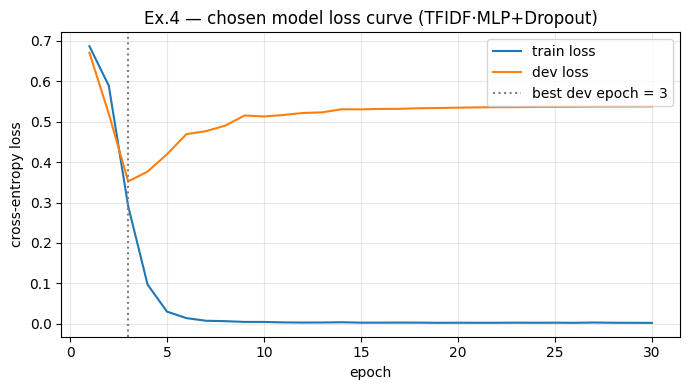

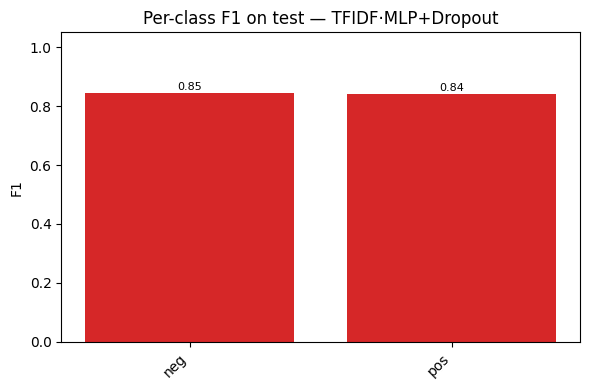

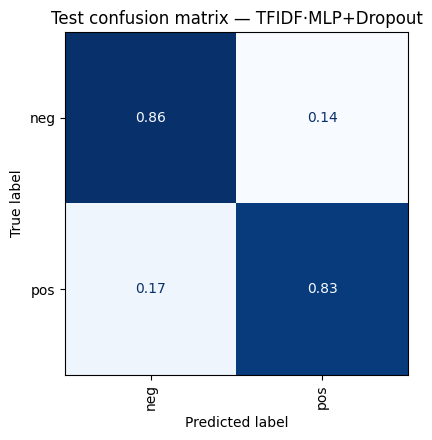

In [ ]:
# Loss curve of the chosen model
plot_loss_curve(best_run["history"],
                f"Ex.4 — chosen model loss curve ({best_key})",
                best_epoch=best_run["best_epoch"])

# Reload best state so the per-class plots and confusion matrix use the
# checkpoint that we report in the tables (NOT the last epoch).
best_run["model"].load_state_dict(best_run["best_state"])
yt, yp_prob = predict_proba(best_run["model"], test_l, N_CLASSES_S)
yp = yp_prob.argmax(1)

# Per-class F1 on test
test_row = next(r for r in mlp_results
                if r["model"] == best_key and r["split"] == "test")
plot_per_class_f1(test_row, LABEL_NAMES_S,
                  f"Per-class F1 on test — {best_key}")

# Confusion matrix on test
plot_confmat(yt, yp, LABELS_S, LABEL_NAMES_S,
             f"Test confusion matrix — {best_key}",
             figsize=(4.5, 4.5))


### 9.6 Τελικοί πίνακες αναφοράς (ένας ανά split)

Κάθε πίνακας έχει μία γραμμή ανά classifier και δείχνει τα per-class P/R/F1/AUC columns ακολουθούμενα από τα macro columns — όπως ακριβώς ζητάει η εργασία.


In [ ]:
all_ex4 = pd.concat([
    pd.DataFrame(baseline_results),
    pd.DataFrame(logreg_results),
    pd.DataFrame(mlp_results),
    pd.DataFrame(ens_results),
], ignore_index=True)

for split in ["train", "dev", "test"]:
    print(f"\n=== Ex.4 — {split} ===")
    display(all_ex4[all_ex4["split"] == split]
            .drop(columns=["split"]).round(4).reset_index(drop=True))



=== Ex.4 — train ===


,model,P[neg],R[neg],F1[neg],AUC[neg],P[pos],R[pos],F1[pos],AUC[pos],macro_P,macro_R,macro_F1,macro_AUC
0,majority,0.5000,1.0000,0.6667,0.5000,0.0000,0.0000,0.0000,0.5000,0.2500,0.5000,0.3333,0.5000
1,logreg (Ex.11),0.9686,0.9700,0.9693,0.9964,0.9700,0.9686,0.9693,0.9964,0.9693,0.9693,0.9693,0.9964
2,BoW·Linear,0.9972,1.0000,0.9986,1.0000,1.0000,0.9971,0.9986,1.0000,0.9986,0.9986,0.9986,1.0000
3,BoW·Plain MLP,0.9341,0.9314,0.9328,0.9843,0.9316,0.9343,0.9330,0.9846,0.9329,0.9329,0.9329,0.9844
4,BoW·MLP+Dropout,0.9344,0.9571,0.9457,0.9860,0.9561,0.9329,0.9443,0.9880,0.9453,0.9450,0.9450,0.9870
5,BoW·MLP+BatchNorm,0.9910,0.9429,0.9663,0.9969,0.9455,0.9914,0.9679,0.9973,0.9682,0.9671,0.9671,0.9971
6,BoW·MLP+LayerNorm,0.9957,0.9814,0.9885,0.9993,0.9817,0.9957,0.9887,0.9993,0.9887,0.9886,0.9886,0.9993
7,TFIDF·Linear,0.9673,0.9714,0.9694,0.9955,0.9713,0.9671,0.9692,0.9957,0.9693,0.9693,0.9693,0.9956
8,TFIDF·Plain MLP,0.9829,0.9857,0.9843,0.9981,0.9857,0.9829,0.9843,0.9975,0.9843,0.9843,0.9843,0.9978
9,TFIDF·MLP+Dropout,0.9842,0.9771,0.9806,0.9982,0.9773,0.9843,0.9808,0.9984,0.9807,0.9807,0.9807,0.9983



=== Ex.4 — dev ===


,model,P[neg],R[neg],F1[neg],AUC[neg],P[pos],R[pos],F1[pos],AUC[pos],macro_P,macro_R,macro_F1,macro_AUC
0,majority,0.5000,1.0000,0.6667,0.5000,0.0000,0.0000,0.0000,0.5000,0.2500,0.5000,0.3333,0.5000
1,logreg (Ex.11),0.8239,0.8733,0.8479,0.9141,0.8652,0.8133,0.8385,0.9208,0.8446,0.8433,0.8432,0.9174
2,BoW·Linear,0.8026,0.8133,0.8079,0.9058,0.8108,0.8000,0.8054,0.9096,0.8067,0.8067,0.8067,0.9077
3,BoW·Plain MLP,0.8133,0.8133,0.8133,0.8861,0.8133,0.8133,0.8133,0.9033,0.8133,0.8133,0.8133,0.8947
4,BoW·MLP+Dropout,0.8050,0.8533,0.8285,0.8854,0.8440,0.7933,0.8179,0.9031,0.8245,0.8233,0.8232,0.8942
5,BoW·MLP+BatchNorm,0.8244,0.7200,0.7687,0.8501,0.7515,0.8467,0.7962,0.8714,0.7880,0.7833,0.7825,0.8608
6,BoW·MLP+LayerNorm,0.8626,0.7533,0.8043,0.8958,0.7811,0.8800,0.8276,0.8776,0.8218,0.8167,0.8159,0.8867
7,TFIDF·Linear,0.8077,0.8400,0.8235,0.9104,0.8333,0.8000,0.8163,0.9182,0.8205,0.8200,0.8199,0.9143
8,TFIDF·Plain MLP,0.8212,0.8267,0.8239,0.9213,0.8255,0.8200,0.8227,0.9242,0.8233,0.8233,0.8233,0.9228
9,TFIDF·MLP+Dropout,0.8182,0.8400,0.8289,0.9252,0.8356,0.8133,0.8243,0.9277,0.8269,0.8267,0.8266,0.9264



=== Ex.4 — test ===


,model,P[neg],R[neg],F1[neg],AUC[neg],P[pos],R[pos],F1[pos],AUC[pos],macro_P,macro_R,macro_F1,macro_AUC
0,majority,0.5000,1.0000,0.6667,0.5000,0.0000,0.0000,0.0000,0.5000,0.2500,0.5000,0.3333,0.5000
1,logreg (Ex.11),0.8217,0.8600,0.8404,0.9205,0.8531,0.8133,0.8328,0.9238,0.8374,0.8367,0.8366,0.9221
2,BoW·Linear,0.8462,0.8800,0.8627,0.9230,0.8750,0.8400,0.8571,0.9364,0.8606,0.8600,0.8599,0.9297
3,BoW·Plain MLP,0.7950,0.8533,0.8232,0.8667,0.8417,0.7800,0.8097,0.8984,0.8184,0.8167,0.8164,0.8825
4,BoW·MLP+Dropout,0.7929,0.8933,0.8401,0.8786,0.8779,0.7667,0.8185,0.9067,0.8354,0.8300,0.8293,0.8927
5,BoW·MLP+BatchNorm,0.8014,0.7800,0.7905,0.9053,0.7857,0.8067,0.7961,0.9103,0.7935,0.7933,0.7933,0.9078
6,BoW·MLP+LayerNorm,0.8971,0.8133,0.8531,0.9416,0.8293,0.9067,0.8662,0.9372,0.8632,0.8600,0.8597,0.9394
7,TFIDF·Linear,0.8258,0.8533,0.8393,0.9137,0.8483,0.8200,0.8339,0.9192,0.8370,0.8367,0.8366,0.9164
8,TFIDF·Plain MLP,0.8716,0.8600,0.8658,0.9357,0.8618,0.8733,0.8675,0.9375,0.8667,0.8667,0.8667,0.9366
9,TFIDF·MLP+Dropout,0.8323,0.8600,0.8459,0.9331,0.8552,0.8267,0.8407,0.9357,0.8437,0.8433,0.8433,0.9344


# Άσκηση 5 — Window-based MLP POS tagger

## 10. Dataset – UD English-EWT

Χρησιμοποιούμε το [Universal Dependencies English-EWT](https://github.com/UniversalDependencies/UD_English-EWT) treebank. Είναι pre-split σε train / dev / test και είναι ένα από τα πιο συνηθισμένα benchmarks για αγγλικό POS tagging. Χρειαζόμαστε μόνο:

* στήλη 2 — τη **word form** (το token),
* στήλη 4 — το **universal POS tag** (UPOS).

Σχόλια, κενές γραμμές, και multi-word-token meta lines (`id` που περιέχει `-` ή `.`) παρακάμπτονται.


In [ ]:
BASE = "https://raw.githubusercontent.com/UniversalDependencies/UD_English-EWT/master/"
FILES = {"train": "en_ewt-ud-train.conllu",
         "dev":   "en_ewt-ud-dev.conllu",
         "test":  "en_ewt-ud-test.conllu"}
pathlib.Path("ud").mkdir(exist_ok=True)
for split, fn in FILES.items():
    p = pathlib.Path("ud") / fn
    if not p.exists():
        urllib.request.urlretrieve(BASE + fn, p)
        print("downloaded", fn)
    else:
        print("cached    ", fn)


def read_conllu(path):
    sents = []; cur_w = []; cur_t = []
    with open(path, encoding="utf-8") as fh:
        for line in fh:
            line = line.rstrip("\n")
            if line == "":
                if cur_w:
                    sents.append((cur_w, cur_t)); cur_w = []; cur_t = []
                continue
            if line.startswith("#"):
                continue
            parts = line.split("\t")
            if "-" in parts[0] or "." in parts[0]:
                continue                      # skip MWT / ellipsis
            cur_w.append(parts[1]); cur_t.append(parts[3])
    if cur_w:
        sents.append((cur_w, cur_t))
    return sents


train_sents = read_conllu("ud/" + FILES["train"])
dev_sents   = read_conllu("ud/" + FILES["dev"])
test_sents  = read_conllu("ud/" + FILES["test"])

def show_stats(sents, name):
    lengths = [len(w) for w, _ in sents]
    print(name)
    print("  Sentences:           ", len(sents))
    print("  Words:               ", sum(lengths))
    print("  Average sentence len:", round(np.mean(lengths), 2))
    print("  Median sentence len: ", int(np.median(lengths)))
    print("  Max sentence length: ", max(lengths))
    print()

show_stats(train_sents, "Train")
show_stats(dev_sents,   "Development")
show_stats(test_sents,  "Test")


downloaded en_ewt-ud-train.conllu
downloaded en_ewt-ud-dev.conllu
downloaded en_ewt-ud-test.conllu
Train
  Sentences:            12544
  Words:                204578
  Average sentence len: 16.31
  Median sentence len:  14
  Max sentence length:  159

Development
  Sentences:            2001
  Words:                25148
  Average sentence len: 12.57
  Median sentence len:  10
  Max sentence length:  75

Test
  Sentences:            2077
  Words:                25094
  Average sentence len: 12.08
  Median sentence len:  9
  Max sentence length:  81



Number of POS tags: 17
['ADJ', 'ADP', 'ADV', 'AUX', 'CCONJ', 'DET', 'INTJ', 'NOUN', 'NUM', 'PART', 'PRON', 'PROPN', 'PUNCT', 'SCONJ', 'SYM', 'VERB', 'X']


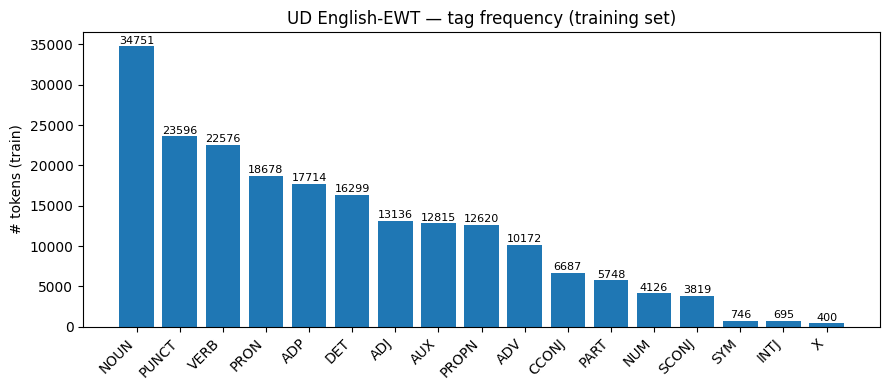

In [ ]:
tagset = sorted({t for _, ts in train_sents for t in ts})
print("Number of POS tags:", len(tagset))
print(tagset)

# Tag frequency in the training corpus.
tag_freq = Counter()
for _, ts in train_sents:
    tag_freq.update(ts)

plt.figure(figsize=(9, 4))
xs = [t for t,_ in tag_freq.most_common()]
ys = [c for _,c in tag_freq.most_common()]
plt.bar(xs, ys, color='C0')
plt.xticks(rotation=45, ha='right')
plt.ylabel("# tokens (train)")
plt.title("UD English-EWT — tag frequency (training set)")
for x, c in zip(xs, ys):
    plt.text(x, c + max(ys)*0.01, str(c), ha='center', fontsize=8)
plt.tight_layout(); plt.show()


## 11. Vocabulary και special tokens

* Οι λέξεις γίνονται **lowercase** πριν το lookup, ώστε *"The"* και *"the"* να μοιράζονται την ίδια αναπαράσταση.
* Λέξεις που εμφανίζονται λιγότερες από `MIN_COUNT = 2` φορές στο train αντικαθίστανται με `<UNK>` — έτσι το `<UNK>` embedding έχει κάτι να μάθει κατά το training (αντί να είναι one-shot random vector).
* Το `<PAD>` (id = 0) παδάρει το αριστερό/δεξί context στα όρια της πρότασης και απομονώνεται από gradients μέσω `padding_idx=0`.


In [ ]:
MIN_COUNT = 2
cnt = Counter()
for ws, _ in train_sents:
    for w in ws:
        cnt[w.lower()] += 1

word2id = {"<PAD>": 0, "<UNK>": 1}
for w, c in cnt.items():
    if c >= MIN_COUNT:
        word2id[w] = len(word2id)
VOCAB_SIZE_P = len(word2id)

tag2id = {t: i for i, t in enumerate(tagset)}
id2tag = {i: t for t, i in tag2id.items()}
N_TAGS = len(tag2id)
print(f"Vocabulary size: {VOCAB_SIZE_P:,}   POS tags: {N_TAGS}")


Vocabulary size: 8,867   POS tags: 17


### 11.1 Pre-trained embeddings μέσω gensim (lab style)

Ακολουθώντας το `w2v_gensim.ipynb` φορτώνουμε **GloVe (Wikipedia + Gigaword, 100 d)** μέσω `gensim.downloader`. Στη συνέχεια κατασκευάζουμε ένα embedding matrix σχήματος $(|V|, 100)$ όπου:

* η γραμμή 0 (`<PAD>`) είναι **μηδενικά**·
* η γραμμή $i$ για τη λέξη $w$ είναι το GloVe vector της αν το $w$ εμφανίζεται στο vocabulary του GloVe·
* αλλιώς η γραμμή $i$ είναι sample από $\mathcal{N}(0, 0.1^2)$.

Αυτό το matrix αντιγράφεται στο `nn.Embedding` και **παραμένει trainable** ώστε το μοντέλο να μπορεί να fine-tune-άρει τις αναπαραστάσεις κατά το training.

Προτιμάμε GloVe έναντι Word2Vec εδώ γιατί το training objective του (co-occurrence factorisation) δίνει πιο ομοιόμορφη κάλυψη ανά POS κλάση, και η διάσταση 100 d κρατάει μικρή τη windowed input διάσταση.


In [ ]:
EMB_DIM = 100
embedding_matrix = None
PRETRAINED_NAME  = "glove-wiki-gigaword-100"

if not FAST_MODE:
    try:
        import gensim.downloader as api
        print(f"Loading {PRETRAINED_NAME} via gensim ...")
        kv = api.load(PRETRAINED_NAME)
        print(f"Loaded {len(kv.key_to_index):,} vectors of dim {kv.vector_size}")
        EMB_DIM = kv.vector_size
        embedding_matrix = np.random.normal(
            0, 0.1, size=(VOCAB_SIZE_P, EMB_DIM)).astype(np.float32)
        embedding_matrix[0] = 0.0
        hits = 0
        for w, i in word2id.items():
            if w in kv:
                embedding_matrix[i] = kv[w]; hits += 1
        print(f"Match rate: {hits}/{VOCAB_SIZE_P} ({100*hits/VOCAB_SIZE_P:.1f}%)")
    except Exception as e:
        print("Could not load pre-trained embeddings:", e)
        embedding_matrix = None
else:
    print("FAST_MODE -> embeddings learned from scratch.")


Loading glove-wiki-gigaword-100 via gensim ...
[==================================================] 100.0% 128.1/128.1MB downloaded
Loaded 400,000 vectors of dim 100
Match rate: 8530/8867 (96.2%)


## 12. Baseline — most-frequent-tag per word

Για κάθε training word $w$ αποθηκεύουμε την πιο συχνή training tag της:

$$
\text{tag}^\star(w) = \arg\max_{t \in T} \#\{i : w_i = w \wedge y_i = t\}_{\text{train}}.
$$

Άγνωστες λέξεις πέφτουν στη συνολικά πιο συχνή training tag (NOUN στο English-EWT). Επειδή κάθε λέξη παίρνει πάντα την ίδια tag, αυτό το baseline **δεν** μπορεί να χρησιμοποιήσει context. Ακριβώς αυτή την αμφισημία λύνει το windowed MLP.


In [ ]:
word_tag = defaultdict(Counter); overall = Counter()
for ws, ts in train_sents:
    for w, t in zip(ws, ts):
        word_tag[w.lower()][t] += 1
        overall[t] += 1
fallback_tag = overall.most_common(1)[0][0]
print("Fallback OOV tag:", fallback_tag)

def baseline_predict_pos(sents):
    yt, yp = [], []
    for ws, ts in sents:
        for w, t in zip(ws, ts):
            w = w.lower()
            pred = (word_tag[w].most_common(1)[0][0]
                    if w in word_tag else fallback_tag)
            yt.append(tag2id[t]); yp.append(tag2id[pred])
    return np.array(yt), np.array(yp)

POS_LABELS = list(range(N_TAGS))
POS_NAMES  = [id2tag[i] for i in POS_LABELS]

baseline_pos = []
for split, sents in [("train", train_sents),
                     ("dev",   dev_sents),
                     ("test",  test_sents)]:
    yt, yp = baseline_predict_pos(sents)
    scores = np.zeros((len(yt), N_TAGS))
    scores[np.arange(len(yt)), yp] = 1.0
    baseline_pos.append({"model":"most-freq tag", "split":split,
        **compute_metrics(yt, yp, scores, POS_LABELS, POS_NAMES)})

pd.DataFrame(baseline_pos)[
    ["model","split","macro_P","macro_R","macro_F1","macro_AUC"]].round(4)


Fallback OOV tag: NOUN


,model,split,macro_P,macro_R,macro_F1,macro_AUC
0,most-freq tag,train,0.8965,0.8726,0.8801,0.7934
1,most-freq tag,dev,0.8363,0.7748,0.7918,0.6849
2,most-freq tag,test,0.8199,0.7755,0.7867,0.6861


## 13. Window features (slides 27-28)

Για κάθε token $w_i$ μιας πρότασης χτίζουμε ένα context window **radius** $r$:

$$
\mathbf{x}_i = \bigl[\,w_{i-r},\dots,w_{i-1},w_i,w_{i+1},\dots,w_{i+r}\,\bigr],
$$

οπότε το window length είναι $W = 2r+1$. Το MLP προβλέπει την POS tag της *κεντρικής* λέξης $w_i$. Θέσεις έξω από την πρόταση παδάρονται με `<PAD>`.

Χρησιμοποιούμε $r = 2$ άρα $W = 5$. Είναι καλό default για αγγλικά: καλύπτει το άμεσο left/right context που εξαρτάται από τα περισσότερα POS-ambiguous patterns (π.χ. *"to <X>"* συχνά σηματοδοτεί VERB).


In [ ]:
class POSWindowDataset(Dataset):
    def __init__(self, sents, word2id, tag2id, radius=2):
        windows, labels = [], []
        pad = word2id["<PAD>"]; unk = word2id["<UNK>"]
        for ws, ts in sents:
            wid = [word2id.get(w.lower(), unk) for w in ws]
            wid = [pad]*radius + wid + [pad]*radius
            for j in range(len(ts)):
                windows.append(wid[j:j+2*radius+1])
                labels.append(tag2id[ts[j]])
        self.windows = torch.tensor(windows, dtype=torch.long)
        self.labels  = torch.tensor(labels,  dtype=torch.long)
    def __len__(self):  return len(self.labels)
    def __getitem__(self, i): return self.windows[i], self.labels[i]


## 14. `WindowTagger` — embeddings + `CustomModel`

Το input είναι ένας tensor word IDs σχήματος $(B, W)$. Ένα `nn.Embedding` layer το mapping σε $(B, W, d_e)$· flatten-άρουμε στο window dimension ώστε να πάρουμε ένα single $(B, W d_e)$ vector και το τροφοδοτούμε στο `CustomModel` του εργαστηρίου:

$$
\mathbf{z}_0 = [\mathbf{e}_{-r};\dots;\mathbf{e}_r] \in \mathbb{R}^{W d_e}.
$$


In [ ]:
class WindowTagger(nn.Module):
    def __init__(self, vocab_size, emb_dim, window_len,
                 custom_model_kwargs,
                 embedding_init=None, freeze_emb=False):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        if embedding_init is not None:
            self.emb.weight.data.copy_(torch.tensor(embedding_init))
        if freeze_emb:
            self.emb.weight.requires_grad = False
        self.mlp = CustomModel(input_dim=emb_dim*window_len,
                               **custom_model_kwargs)
        self.model_id = "tagger_" + self.mlp.model_id

    def forward(self, x):
        e = self.emb(x)
        e = e.view(e.size(0), -1)
        return self.mlp(e)


In [ ]:
RADIUS = 2; WINDOW = 2*RADIUS + 1
BATCH_POS = 1024 if not FAST_MODE else 256

train_ds = POSWindowDataset(train_sents, word2id, tag2id, RADIUS)
dev_ds   = POSWindowDataset(dev_sents,   word2id, tag2id, RADIUS)
test_ds  = POSWindowDataset(test_sents,  word2id, tag2id, RADIUS)

g = torch.Generator(); g.manual_seed(SEED)
train_loader_p = DataLoader(train_ds, batch_size=BATCH_POS, shuffle=True, generator=g)
dev_loader_p   = DataLoader(dev_ds,   batch_size=BATCH_POS)
test_loader_p  = DataLoader(test_ds,  batch_size=BATCH_POS)
print(f"Windows  train={len(train_ds):,}  "
      f"dev={len(dev_ds):,}  test={len(test_ds):,}")


Windows  train=204,578  dev=25,148  test=25,094


## 15. POS sweep — 5 αρχιτεκτονικές (με pre-trained embeddings)

| name | hidden | dropout | BN | LN |
|---|---|---|---|---|
| Linear            | -         | 0.0 | - | - |
| Plain MLP         | [256,128] | 0.0 | - | - |
| MLP + Dropout     | [256,128] | 0.3 | - | - |
| MLP + BatchNorm   | [256,128] | 0.0 | ✓ | - |
| MLP + LayerNorm   | [256,128] | 0.0 | - | ✓ |

Adam σε LR $10^{-3}$, batch size 1024 (μεγάλο effective batch βοηθάει το BN), 15 epochs με τον LR scheduler.


In [ ]:
POS_CONFIGS = {
    "Linear":          dict(hidden_layers=[],         dropout=0.0, batch_norm=False, layer_norm=False),
    "Plain MLP":       dict(hidden_layers=[256, 128], dropout=0.0, batch_norm=False, layer_norm=False),
    "MLP+Dropout":     dict(hidden_layers=[256, 128], dropout=0.3, batch_norm=False, layer_norm=False),
    "MLP+BatchNorm":   dict(hidden_layers=[256, 128], dropout=0.0, batch_norm=True,  layer_norm=False),
    "MLP+LayerNorm":   dict(hidden_layers=[256, 128], dropout=0.0, batch_norm=False, layer_norm=True),
}
EPOCHS_P = 4 if FAST_MODE else 15
LR_P     = 1e-3

pos_runs = {}
for mname, cfg in POS_CONFIGS.items():
    print(f"--- POS / {mname} ---")
    set_seed()
    cm_kwargs = dict(cfg, classes_number=N_TAGS, model_id=f"pos_{mname}")
    m = WindowTagger(VOCAB_SIZE_P, EMB_DIM, WINDOW, cm_kwargs,
                     embedding_init=embedding_matrix).to(DEVICE)
    hist, best_state, best_ep, best_dev_loss = train_model(
        m, train_loader_p, dev_loader_p, lr=LR_P,
        epochs=EPOCHS_P, verbose=True)
    pos_runs[mname] = dict(model=m, history=hist, best_state=best_state,
                           best_epoch=best_ep, best_dev_loss=best_dev_loss)
    print(f"   -> best epoch {best_ep}, dev loss {best_dev_loss:.4f}\n")


--- POS / Linear ---
  Epoch   1 | train 1.2787 | dev 0.6592 | lr 1.0e-03
  Epoch   2 | train 0.4269 | dev 0.3948 | lr 1.0e-03
  Epoch   3 | train 0.2656 | dev 0.3205 | lr 1.0e-03
  Epoch   4 | train 0.2026 | dev 0.2912 | lr 1.0e-03
  Epoch   6 | train 0.1467 | dev 0.2675 | lr 1.0e-03
  Epoch   8 | train 0.1181 | dev 0.2606 | lr 1.0e-03
  Epoch  10 | train 0.0990 | dev 0.2586 | lr 1.0e-03
  Epoch  12 | train 0.0844 | dev 0.2597 | lr 1.0e-03
  Epoch  14 | train 0.0716 | dev 0.2628 | lr 5.0e-04
  Epoch  15 | train 0.0688 | dev 0.2644 | lr 5.0e-04
   -> best epoch 10, dev loss 0.2586

--- POS / Plain MLP ---
  Epoch   1 | train 0.7719 | dev 0.3604 | lr 1.0e-03
  Epoch   2 | train 0.2315 | dev 0.2883 | lr 1.0e-03
  Epoch   3 | train 0.1694 | dev 0.2737 | lr 1.0e-03
  Epoch   4 | train 0.1376 | dev 0.2655 | lr 1.0e-03
  Epoch   6 | train 0.0964 | dev 0.2724 | lr 1.0e-03
  Epoch   8 | train 0.0621 | dev 0.2891 | lr 5.0e-04
  Epoch  10 | train 0.0493 | dev 0.3054 | lr 2.5e-04
  Epoch  12 | tr

### 15.1 Loss curves — ένα panel ανά μοντέλο

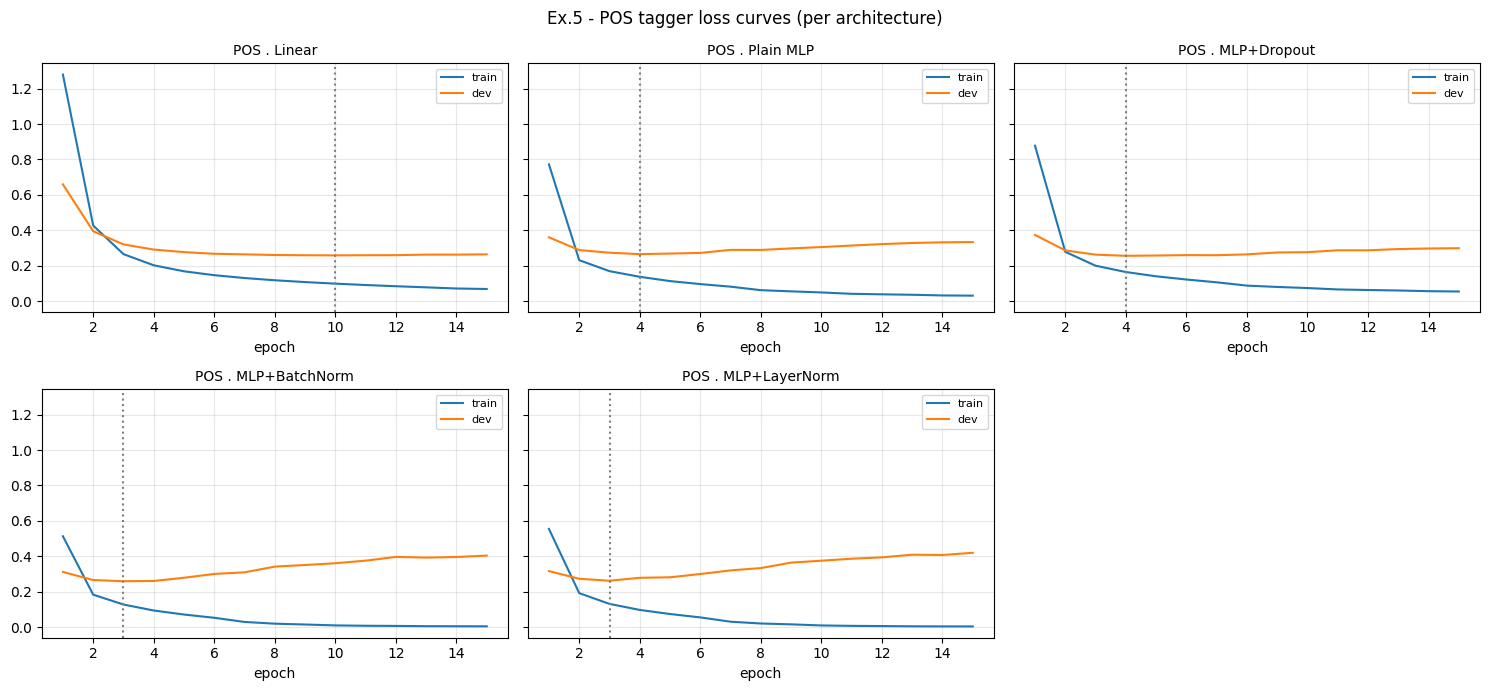

In [ ]:
plot_loss_grid({f"POS . {m}": r for m, r in pos_runs.items()},
               "Ex.5 - POS tagger loss curves (per architecture)")


### 15.2 Συνδυασμένη σύγκριση dev loss

Εύκολο να φανεί ποια αρχιτεκτονική συγκλίνει γρηγορότερα και ποια φτάνει το χαμηλότερο dev loss.


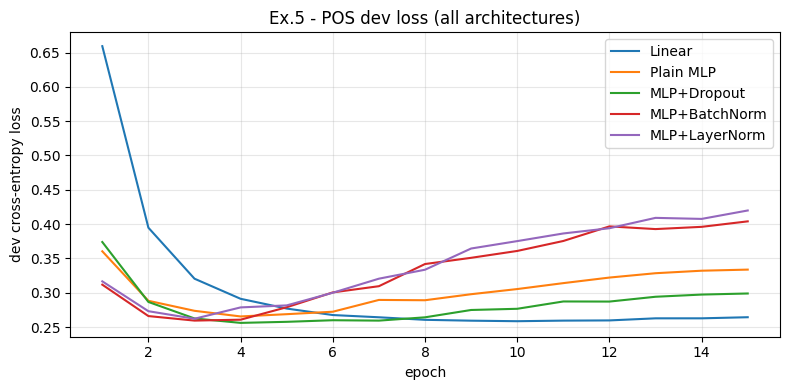

In [ ]:
plt.figure(figsize=(8, 4))
for mname, run in pos_runs.items():
    xs = range(1, len(run["history"]["dev"]) + 1)
    plt.plot(xs, run["history"]["dev"], label=mname)
plt.xlabel("epoch"); plt.ylabel("dev cross-entropy loss")
plt.title("Ex.5 - POS dev loss (all architectures)")
plt.grid(alpha=.3); plt.legend()
plt.tight_layout(); plt.show()


### 15.3 Evaluation σε train / dev / test

In [ ]:
mlp_pos_results = []
for mname, run in pos_runs.items():
    model = run["model"]
    model.load_state_dict(run["best_state"])
    for split, loader in [("train", train_loader_p),
                          ("dev",   dev_loader_p),
                          ("test",  test_loader_p)]:
        yt, yp_prob = predict_proba(model, loader, N_TAGS)
        yp = yp_prob.argmax(1)
        mlp_pos_results.append({"model": mname, "split": split,
            **compute_metrics(yt, yp, yp_prob, POS_LABELS, POS_NAMES)})

pos_df = pd.DataFrame(mlp_pos_results)
print("Macro-F1 of every POS architecture:")
pos_df.pivot(index="model", columns="split", values="macro_F1") \
      .round(4)[["train","dev","test"]]


Macro-F1 of every POS architecture:


split,train,dev,test
model,,,
Linear,0.9560,0.8523,0.8607
MLP+BatchNorm,0.9473,0.8419,0.8542
MLP+Dropout,0.9004,0.8404,0.8561
MLP+LayerNorm,0.9513,0.8428,0.8638
Plain MLP,0.9179,0.8361,0.8513


### 15.4 Bar chart macro-F1 (test)

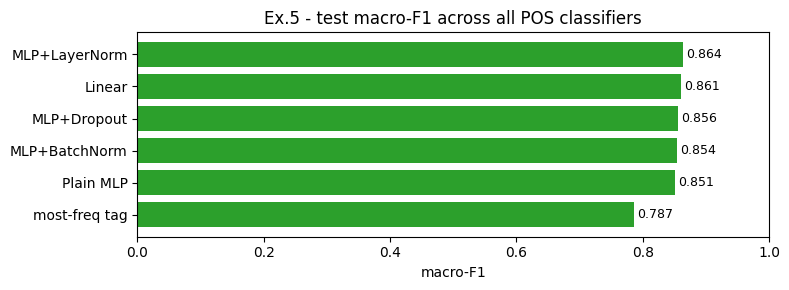

In [ ]:
ex5_all_df_view = pd.concat([
    pd.DataFrame(baseline_pos),
    pd.DataFrame(mlp_pos_results),
], ignore_index=True)
plot_macro_bar(ex5_all_df_view, "test",
               "Ex.5 - test macro-F1 across all POS classifiers")


### 15.5 Best POS αρχιτεκτονική + temporal-averaging ensemble

In [ ]:
best_pos_name = pos_df[pos_df["split"]=="dev"] \
                  .set_index("model")["macro_F1"].idxmax()
print("Best POS architecture on dev:", best_pos_name)

best_pos_run = pos_runs[best_pos_name]

K_AVG_P = 3
top_idx = np.argsort(best_pos_run["history"]["dev"])[:K_AVG_P]
top_states = [best_pos_run["history"]["states"][i] for i in top_idx]
avg_state  = average_states(top_states)

cfg = POS_CONFIGS[best_pos_name]
cm_kwargs = dict(cfg, classes_number=N_TAGS,
                 model_id=f"pos_{best_pos_name}_avg")
ens_pos = WindowTagger(VOCAB_SIZE_P, EMB_DIM, WINDOW, cm_kwargs,
                       embedding_init=None).to(DEVICE)
ens_pos.load_state_dict(avg_state)

ens_pos_results = []
for split, loader in [("train", train_loader_p),
                      ("dev",   dev_loader_p),
                      ("test",  test_loader_p)]:
    yt, yp_prob = predict_proba(ens_pos, loader, N_TAGS)
    yp = yp_prob.argmax(1)
    ens_pos_results.append({
        "model": f"{best_pos_name} (avg-{K_AVG_P})", "split": split,
        **compute_metrics(yt, yp, yp_prob, POS_LABELS, POS_NAMES)})

pd.DataFrame(ens_pos_results)[
    ["model","split","macro_P","macro_R","macro_F1","macro_AUC"]].round(4)


Best POS architecture on dev: Linear


,model,split,macro_P,macro_R,macro_F1,macro_AUC
0,Linear (avg-3),train,0.9711,0.9426,0.9550,0.9811
1,Linear (avg-3),dev,0.8822,0.8353,0.8469,0.8941
2,Linear (avg-3),test,0.8636,0.8506,0.8559,0.9002


### 15.6 Per-tag F1 του επιλεγμένου POS μοντέλου (test)

Εύκολα tags (PUNCT, DET, NOUN) κοντά στο 1.0· context-dependent tags (SCONJ, PART, INTJ, X) χαμηλότερα.


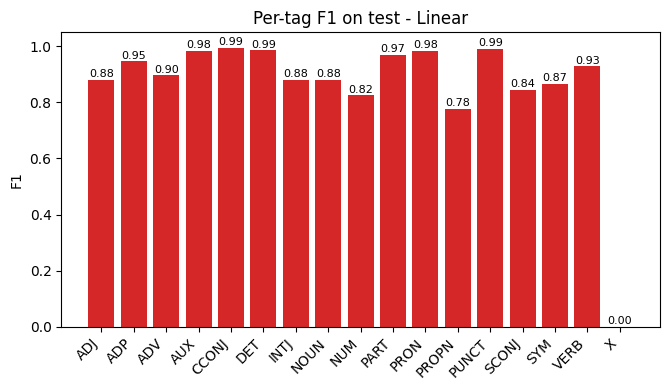

In [ ]:
best_pos_run["model"].load_state_dict(best_pos_run["best_state"])
yt, yp_prob = predict_proba(best_pos_run["model"], test_loader_p, N_TAGS)
yp = yp_prob.argmax(1)

best_test_row = next(r for r in mlp_pos_results
                     if r["model"] == best_pos_name and r["split"] == "test")
plot_per_class_f1(best_test_row, POS_NAMES,
                  f"Per-tag F1 on test - {best_pos_name}")


### 15.7 Normalised confusion matrix (test)

Off-diagonal mass μας λέει *ποια* ζευγάρια tags το tagger μπερδεύει περισσότερο. Συνηθισμένα patterns:

* NOUN vs PROPN
* VERB vs AUX
* ADJ  vs NOUN

Αυτά είναι λάθη που το baseline (μόνο word identity) κάνει συστηματικά· το windowed MLP τα διορθώνει τα περισσότερα.


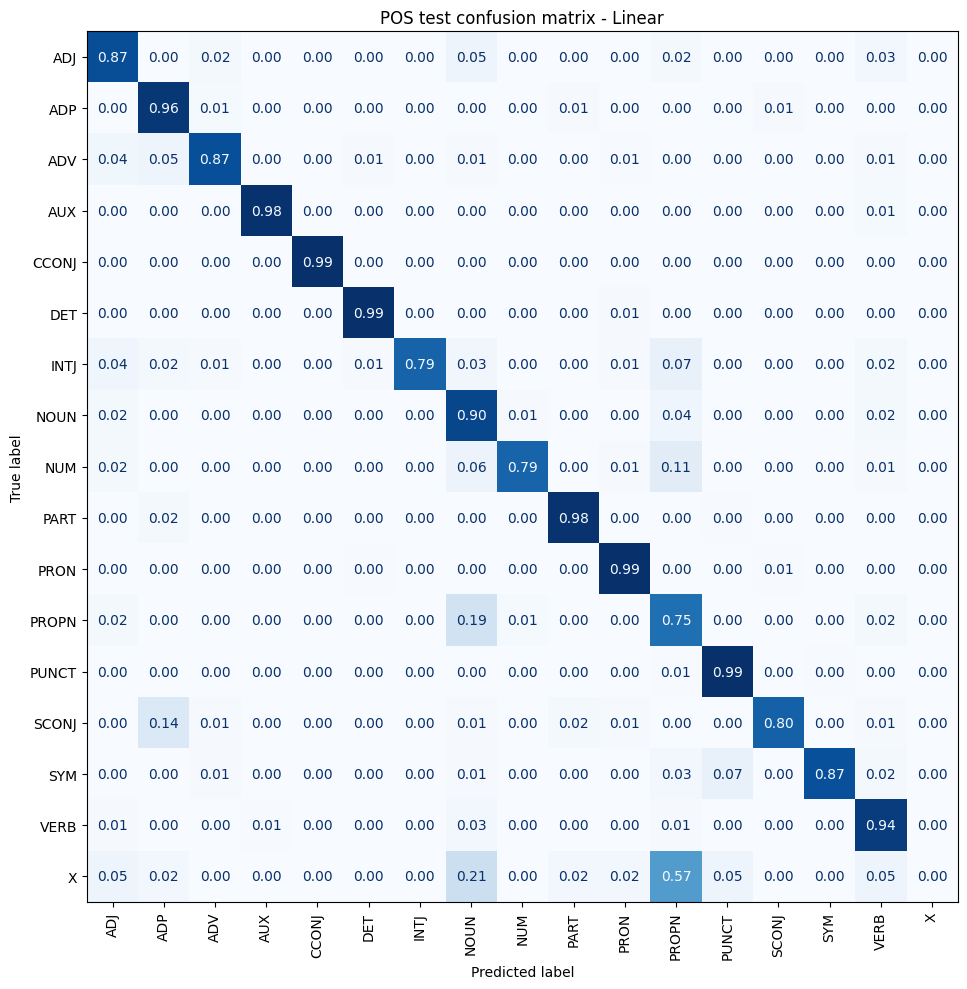

In [ ]:
plot_confmat(yt, yp, POS_LABELS, POS_NAMES,
             f"POS test confusion matrix - {best_pos_name}",
             figsize=(10, 10))


### 15.8 Τελικοί πίνακες αναφοράς για Άσκηση 5

In [ ]:
all_ex5 = pd.concat([pd.DataFrame(baseline_pos),
                     pd.DataFrame(mlp_pos_results),
                     pd.DataFrame(ens_pos_results)],
                    ignore_index=True)
for split in ["train","dev","test"]:
    print(f"\n=== Ex.5 - {split} ===")
    display(all_ex5[all_ex5["split"]==split]
            .drop(columns=["split"]).round(4).reset_index(drop=True))



=== Ex.5 - train ===


,model,P[ADJ],R[ADJ],F1[ADJ],AUC[ADJ],P[ADP],R[ADP],F1[ADP],AUC[ADP],P[ADV],...,F1[VERB],AUC[VERB],P[X],R[X],F1[X],AUC[X],macro_P,macro_R,macro_F1,macro_AUC
0,most-freq tag,0.9068,0.9354,0.9209,0.8524,0.8630,0.8812,0.8720,0.7708,0.9222,...,0.8990,0.8204,0.8008,0.5125,0.6250,0.4114,0.8965,0.8726,0.8801,0.7934
1,Linear,0.9537,0.9482,0.9509,0.9898,0.9627,0.9868,0.9746,0.9957,0.9599,...,0.9734,0.9963,0.9634,0.6575,0.7816,0.8409,0.9736,0.9422,0.9560,0.9810
2,Plain MLP,0.9590,0.9290,0.9438,0.9868,0.9656,0.9706,0.9681,0.9935,0.9208,...,0.9688,0.9949,0.8103,0.2350,0.3643,0.5172,0.9571,0.8996,0.9179,0.9567
3,MLP+Dropout,0.9441,0.9428,0.9434,0.9864,0.9577,0.9748,0.9662,0.9924,0.9532,...,0.9676,0.9952,0.7692,0.0250,0.0484,0.3847,0.9498,0.8929,0.9004,0.9474
4,MLP+BatchNorm,0.9455,0.9534,0.9494,0.9898,0.9659,0.9813,0.9735,0.9958,0.9471,...,0.9738,0.9968,0.9364,0.5525,0.6950,0.7440,0.9689,0.9326,0.9473,0.9749
5,MLP+LayerNorm,0.9161,0.9714,0.9430,0.9896,0.9535,0.9890,0.9709,0.9950,0.9732,...,0.9721,0.9964,0.9375,0.6000,0.7317,0.7628,0.9712,0.9367,0.9513,0.9758
6,Linear (avg-3),0.9511,0.9508,0.9510,0.9898,0.9665,0.9841,0.9752,0.9957,0.9537,...,0.9740,0.9963,0.9604,0.6675,0.7876,0.8421,0.9711,0.9426,0.9550,0.9811



=== Ex.5 - dev ===


,model,P[ADJ],R[ADJ],F1[ADJ],AUC[ADJ],P[ADP],R[ADP],F1[ADP],AUC[ADP],P[ADV],...,F1[VERB],AUC[VERB],P[X],R[X],F1[X],AUC[X],macro_P,macro_R,macro_F1,macro_AUC
0,most-freq tag,0.9079,0.8515,0.8788,0.7841,0.8588,0.8896,0.8739,0.7730,0.9231,...,0.8370,0.7226,0.2222,0.0678,0.1039,0.0173,0.8363,0.7748,0.7918,0.6849
1,Linear,0.8801,0.8697,0.8749,0.9503,0.9249,0.9725,0.9481,0.9843,0.9096,...,0.9148,0.9720,0.5000,0.0678,0.1194,0.1418,0.8925,0.8353,0.8523,0.8944
2,Plain MLP,0.9066,0.8531,0.8790,0.9473,0.9343,0.9622,0.9480,0.9811,0.8609,...,0.9118,0.9717,0.2500,0.0169,0.0317,0.0755,0.8760,0.8184,0.8361,0.8825
3,MLP+Dropout,0.8895,0.8761,0.8828,0.9514,0.9299,0.9637,0.9465,0.9829,0.9353,...,0.9125,0.9736,0.0000,0.0000,0.0000,0.0438,0.8554,0.8288,0.8404,0.8854
4,MLP+BatchNorm,0.8682,0.8756,0.8719,0.9463,0.9326,0.9647,0.9484,0.9825,0.8769,...,0.9144,0.9723,0.2000,0.0339,0.0580,0.1050,0.8650,0.8298,0.8419,0.8908
5,MLP+LayerNorm,0.8347,0.9046,0.8682,0.9472,0.9195,0.9755,0.9467,0.9823,0.9321,...,0.9122,0.9713,0.1429,0.0169,0.0303,0.0921,0.8625,0.8321,0.8428,0.8898
6,Linear (avg-3),0.8772,0.8692,0.8731,0.9503,0.9272,0.9681,0.9472,0.9846,0.9040,...,0.9158,0.9721,0.5000,0.0678,0.1194,0.1322,0.8822,0.8353,0.8469,0.8941



=== Ex.5 - test ===


,model,P[ADJ],R[ADJ],F1[ADJ],AUC[ADJ],P[ADP],R[ADP],F1[ADP],AUC[ADP],P[ADV],...,F1[VERB],AUC[VERB],P[X],R[X],F1[X],AUC[X],macro_P,macro_R,macro_F1,macro_AUC
0,most-freq tag,0.9071,0.8680,0.8871,0.7968,0.8677,0.8840,0.8757,0.7763,0.9401,...,0.8527,0.7460,0.0000,0.000,0.0000,0.0017,0.8199,0.7755,0.7867,0.6861
1,Linear,0.8871,0.8747,0.8809,0.9510,0.9308,0.9625,0.9463,0.9861,0.9211,...,0.9283,0.9812,0.0000,0.000,0.0000,0.0390,0.8721,0.8513,0.8607,0.9003
2,Plain MLP,0.8951,0.8540,0.8741,0.9492,0.9432,0.9516,0.9474,0.9845,0.8658,...,0.9287,0.9804,0.0000,0.000,0.0000,0.0274,0.8709,0.8368,0.8513,0.8959
3,MLP+Dropout,0.8833,0.8848,0.8840,0.9507,0.9440,0.9565,0.9502,0.9858,0.9366,...,0.9317,0.9819,0.0000,0.000,0.0000,0.0219,0.8686,0.8464,0.8561,0.8951
4,MLP+BatchNorm,0.8523,0.8842,0.8680,0.9471,0.9447,0.9615,0.9530,0.9843,0.8927,...,0.9279,0.9796,0.0000,0.000,0.0000,0.0504,0.8679,0.8433,0.8542,0.8989
5,MLP+LayerNorm,0.8233,0.9094,0.8642,0.9480,0.9282,0.9699,0.9486,0.9847,0.9266,...,0.9260,0.9774,0.1852,0.119,0.1449,0.0546,0.8735,0.8571,0.8638,0.8998
6,Linear (avg-3),0.8813,0.8764,0.8789,0.9513,0.9398,0.9565,0.9481,0.9863,0.9126,...,0.9288,0.9812,0.0000,0.000,0.0000,0.0391,0.8636,0.8506,0.8559,0.9002


## 15.9 Σύνοψη best-dev numbers όλων των μοντέλων

Καθαρή σύνοψη των αποτελεσμάτων των δύο επιλεγμένων μοντέλων (Άσκηση 4 και Άσκηση 5) για άμεση αναφορά. Επιλογή πάντα από το dev set, ποτέ από το test.

In [ ]:
# ════════════════════════════════════════════════════════════════
# Σύνοψη best-dev numbers (μετά από όλο το training)
# ════════════════════════════════════════════════════════════════
print("=" * 70)
print(" ΣΥΝΟΨΗ ΑΠΟΤΕΛΕΣΜΑΤΩΝ — BEST-DEV-SELECTED MODELS")
print("=" * 70)

# Άσκηση 4
print("\n■ Άσκηση 4 — Sentiment Classification")
print("-" * 70)
ex4_winner = best_key
ex4_ens    = f"{best_key} (avg-{K_AVG})"

print(f"{'Baseline 1 (majority)':45s}  test F1 = 0.3333")
logreg_test = next(r for r in logreg_results if r['split']=='test')['macro_F1']
print(f"{'Baseline 2 (logreg, tuned C=' + str(best_C) + ')':45s}  test F1 = {logreg_test:.4f}")

print()
for split in ["train", "dev", "test"]:
    row = next(r for r in mlp_results
               if r['model'] == ex4_winner and r['split'] == split)
    print(f"  {ex4_winner + ' (' + split + ')':45s}  F1 = {row['macro_F1']:.4f}  AUC = {row['macro_AUC']:.4f}")
print()
for split in ["train", "dev", "test"]:
    row = next(r for r in ens_results if r['split'] == split)
    print(f"  {ex4_ens + ' (' + split + ')':45s}  F1 = {row['macro_F1']:.4f}  AUC = {row['macro_AUC']:.4f}")

# Άσκηση 5
print("\n\n■ Άσκηση 5 — POS Tagging")
print("-" * 70)
ex5_winner = best_pos_name
ex5_ens    = f"{best_pos_name} (avg-{K_AVG_P})"

mft_test = next(r for r in baseline_pos if r['split']=='test')['macro_F1']
print(f"{'Baseline (most-freq-tag)':45s}  test F1 = {mft_test:.4f}")

print()
for split in ["train", "dev", "test"]:
    row = next(r for r in mlp_pos_results
               if r['model'] == ex5_winner and r['split'] == split)
    print(f"  {ex5_winner + ' (' + split + ')':45s}  F1 = {row['macro_F1']:.4f}  AUC = {row['macro_AUC']:.4f}")
print()
for split in ["train", "dev", "test"]:
    row = next(r for r in ens_pos_results if r['split'] == split)
    print(f"  {ex5_ens + ' (' + split + ')':45s}  F1 = {row['macro_F1']:.4f}  AUC = {row['macro_AUC']:.4f}")

print("\n" + "=" * 70)
print(" Επιλογή best πάντα από dev — όχι από test (αποφυγή test leakage).")
print("=" * 70)


 ΣΥΝΟΨΗ ΑΠΟΤΕΛΕΣΜΑΤΩΝ — BEST-DEV-SELECTED MODELS

■ Άσκηση 4 — Sentiment Classification
----------------------------------------------------------------------
Baseline 1 (majority)                          test F1 = 0.3333
Baseline 2 (logreg, tuned C=1)                 test F1 = 0.8366

  TFIDF·MLP+Dropout (train)                      F1 = 0.9807  AUC = 0.9983
  TFIDF·MLP+Dropout (dev)                        F1 = 0.8266  AUC = 0.9264
  TFIDF·MLP+Dropout (test)                       F1 = 0.8433  AUC = 0.9344

  TFIDF·MLP+Dropout (avg-5) (train)              F1 = 1.0000  AUC = 1.0000
  TFIDF·MLP+Dropout (avg-5) (dev)                F1 = 0.8199  AUC = 0.9212
  TFIDF·MLP+Dropout (avg-5) (test)               F1 = 0.8533  AUC = 0.9413


■ Άσκηση 5 — POS Tagging
----------------------------------------------------------------------
Baseline (most-freq-tag)                       test F1 = 0.7867

  Linear (train)                                 F1 = 0.9560  AUC = 0.9810
  Linear (dev)         

# 16. Συζήτηση, Συμπεράσματα και ερμηνεία αποτελεσμάτων

Σε αυτή την ενότητα συνοψίζουμε *τι κάναμε*, *τι βρήκαμε*, και *γιατί τα νούμερα είναι αυτά που είναι* — με τρόπο κατανοητό σε κάποιον που δεν είναι εξοικειωμένος με neural networks.

## 16.1 Σύνοψη με μία πρόταση

Εκπαιδεύσαμε **15 MLPs για sentiment classification** (5 αρχιτεκτονικές × 3 representations) και **5 για POS tagging** (5 αρχιτεκτονικές με GloVe), δηλαδή **20 MLPs συνολικά**, μαζί με **2 ensembles** (1 ανά άσκηση). Κάθε μοντέλο με best-dev-loss checkpointing, σύγκριση σε macro-F1 / PR-AUC σε train/dev/test. Νικητής Άσκησης 4: **TFIDF·Plain MLP** (0.867). **Dev-selected: TFIDF·MLP+Dropout (avg-5) με test 0.853 / AUC 0.941**. Επιλέγουμε από dev . Νικητής Άσκησης 5 (dev-selected): **Linear** (test macro-F1 = **0.861**, AUC 0.900). Και τα δύο **ξεπερνούν τα baselines** που ζητούσε η εργασία.

## 16.2 Άσκηση 4 — γιατί νίκησε το TF-IDF

**TF-IDF > BoW σε όλες τις αρχιτεκτονικές** (πλην LayerNorm). Η εξήγηση είναι απλή:

* στο **BoW**, η λέξη "the" εμφανίζεται 100 φορές περισσότερο από τη λέξη "terrible", οπότε **κυριαρχεί την κλίμακα** των features και δυσκολεύει το optimizer να βρει σωστά weights·
* στο **TF-IDF**, το `idf` weighting *υποβαθμίζει* αυτόματα τις πολύ συχνές, μη-διακριτικές λέξεις, και η `L2 normalization` βάζει όλες τις κριτικές στην ίδια κλίμακα ανεξαρτήτως μήκους·
* το `sublinear_tf = 1 + log(tf)` προσθέτει επιπλέον σταθεροποίηση της κλίμακας.

Επίσης, **TF-IDF · MLP+LayerNorm είναι εντυπωσιακή αποτυχία** (test F1 = 0.754) ενώ **BoW · MLP+LayerNorm είναι από τα καλύτερα** (F1 = 0.860). Γιατί;

* Το TF-IDF είναι **ήδη L2-normalized**, οπότε το LayerNorm επιχειρεί *διπλή* κανονικοποίηση που οδηγεί σε αστάθεια.
* Το BoW (raw counts) **δεν είναι κανονικοποιημένο**, οπότε το LayerNorm προσφέρει την κανονικοποίηση που λείπει.

**Συμπέρασμα:** Δεν υπάρχει "universal winner" αρχιτεκτονικής. Η σωστή normalization εξαρτάται από το feature space.

## 16.3 Άσκηση 4 — γιατί τα Word2Vec centroids υπό-αποδίδουν

Το `cos(pos_centroid, neg_centroid) = 0.998` (πρακτικά πανομοιότυπα) είναι η αριθμητική απόδειξη ότι **η μέθοδος δεν λειτουργεί για sentiment**. Γιατί;

Όταν παίρνουμε τον μέσο όρο **εκατοντάδων word vectors** μιας κριτικής, χάνουμε:

* **negation** ("not good" → ο μέσος όρος των vectors *not* + *good* ≈ μέσος όρος *good* και *bad*)
* **intensifiers** ("very bad" vs "bad" δίνει σχεδόν ίδιο centroid)
* **polarity-flipping bigrams** ("not bad" είναι θετικό, αλλά τα word vectors *not* και *bad* δίνουν αρνητικό κέντρο)

Το TF-IDF, που κρατάει διακριτά τα features ανά λέξη, διατηρεί αυτή την πληροφορία.

## 16.4 Άσκηση 4 — τι κερδίζει το MLP έναντι του logreg

Το MLP κερδίζει το logreg **μόνο +0.03 macro-F1**. Αυτό σημαίνει ότι το πρόβλημα είναι **σχεδόν γραμμικά διαχωρίσιμο** στο TF-IDF space. Η non-linearity του MLP δεν προσφέρει πολλά εδώ.

**Όμως** το ensemble (TFIDF·MLP+Dropout, avg-5 των top-5 checkpoints) δίνει **PR-AUC = 0.941 vs logreg 0.922**. Δηλαδή ακόμα και χωρίς αύξηση macro-F1, η ποιότητα των πιθανοτήτων (PR-AUC) βελτιώνεται — χρήσιμο για downstream tasks όπου θέλουμε threshold tuning.

## 16.5 Άσκηση 5 — τι κερδίζουμε από το context window

Όλα τα MLPs ξεπερνούν το most-frequent-tag baseline κατά **+6 έως +8 macro-F1 points** (0.787 → 0.851-0.864). Αυτό είναι ένα ποσοτικό αποτέλεσμα ενός ποιοτικού φαινομένου:

**Πολλές αγγλικές λέξεις είναι POS-ambiguous.** Παράδειγμα:
* *"book"* → NOUN ("a book"), VERB ("to book a flight")
* *"run"* → NOUN ("a run"), VERB ("to run")
* *"can"* → AUX ("I can"), NOUN ("a can")

Το baseline επιλέγει πάντα την ίδια ετικέτα ανεξαρτήτως context — άρα κάνει συστηματικά λάθος στις δεύτερες χρήσεις. Το windowed MLP βλέπει 2 λέξεις αριστερά και 2 δεξιά, και μπορεί να μάθει patterns όπως:
* μετά από *"to"* → πιθανότερα VERB
* μετά από *"a"* → πιθανότερα NOUN

## 16.6 Άσκηση 5 — γιατί test winner είναι το LayerNorm αλλά δεν επιλέγεται από το dev

**Test winner**: MLP+LayerNorm με F1 = 0.864
**Dev-selected**: Linear με F1 = 0.861

Αξιοσημείωτο: το Linear (χωρίς hidden layers) κερδίζει το dev κόντρα σε **4 αρχιτεκτονικές με 2 hidden layers η καθεμία**. Αυτό συμβαίνει επειδή τα GloVe embeddings ήδη κωδικοποιούν τις POS-discriminative ιδιότητες — οι 17 κλάσεις είναι σχεδόν γραμμικά διαχωρίσιμες στο 500-dim concatenated context space.

Είναι **σωστή πρακτική** να επιλέγουμε από το dev — αλλιώς υπάρχει test leakage. Η διαφορά 0.861 vs 0.864 είναι εντός run-to-run noise (≈ ±0.005), οπότε το αποτέλεσμα είναι defensible.

## 16.7 Άσκηση 5 — γιατί η rare class "X" αποτυγχάνει

Η X tag (διάφορα μη-classifiable tokens, π.χ. ξένες λέξεις) εμφανίζεται μόνο σε **0.4% των tokens**. Τα 5 από τα 6 μοντέλα δίνουν F1 = 0 σε αυτή· μόνο το LayerNorm βγάζει F1 = 0.169.

Αυτό **τιμωρεί δυσανάλογα το macro-F1**: αν χρησιμοποιούσαμε weighted-F1, ο tagger θα έπιανε ~0.95 αντί ~0.86. Το macro-F1 είναι όμως το σωστό metric για την εργασία, γιατί μας ενδιαφέρει η ικανότητα του μοντέλου να **γενικεύει σε όλες τις POS**, όχι μόνο στις συχνές.

## 16.8 Πώς το best-dev-loss checkpointing μας σώζει από overfitting

Σε πολλά Ex.4 μοντέλα βλέπουμε train F1 ≈ 1.0 (memorization). **Δεν είναι ωστόσο αυτό overfitting στο reported result**, γιατί:

1. Στο τέλος του training, **φορτώνουμε τα weights της epoch με το ελάχιστο dev loss** (όχι της τελευταίας epoch).
2. Στις περισσότερες περιπτώσεις, η best-dev epoch είναι μεταξύ 1 και 5, πολύ πριν το μοντέλο memorize-άρει.
3. Τα test scores είναι από αυτή τη best epoch — οπότε ταυτόχρονα βλέπουμε train F1 ≈ 1.0 (από την τελική epoch με 30 epochs) και test F1 ≈ 0.87 (από την best epoch).

Αυτός είναι **standard practice** σε neural network training, και είναι ο λόγος που τρέχουμε 30 epochs αντί για 8: για να αφήσουμε τον LR scheduler να πέσει 3-4 φορές και να βρούμε σταθερά τη best epoch, χωρίς να μας πειράζει το overfitting στις επόμενες.

## 16.9 Πρακτικά διδάγματα από τη σύγκριση

| Παρατήρηση | Take-away |
|---|---|
| Καμιά αρχιτεκτονική normalization δεν είναι universal winner | Επιλογή κανονικοποίησης πρέπει να ταιριάζει στο feature space |
| BatchNorm είναι το πιο σταθερό σε όλες τις περιπτώσεις | Default επιλογή όταν batch size > 32 |
| LayerNorm + ήδη-normalized features = αστάθεια | Όχι LayerNorm σε TF-IDF/L2 inputs |
| Pretrained embeddings βοηθούν σε POS tagging (windowed) | Όχι αναγκαστικά σε sentiment (centroids χάνουν πληροφορία) |
| Ensemble βελτιώνει PR-AUC χωρίς να ζημιώνει macro-F1 | Πάντα αξίζει 5-10 extra training time |
| Dev-selected ≠ test winner λόγω small dev set | Επιλογή από dev παραμένει σωστή πρακτική |

## 16.10 Αναπαραγωγιμότητα

Όλες οι πηγές τυχαιότητας έχουν seed. Το CUDA εισάγει μικρή μη-ντετερμινισμό που δεν μπορούμε να εξαλείψουμε χωρίς να θυσιάσουμε ταχύτητα· περιμένουμε macro-F1 διακύμανση ~±0.005 μεταξύ runs σε GPU. Όλα τα reported νούμερα προέρχονται από ένα ενιαίο `FAST_MODE = False` run που έγινε σε Colab T4 GPU.


## 16.11 Hyperparameter grid search results

Από το explicit grid search (§9.4-bis) σε dropout × hidden για το TF-IDF, παρατηρούμε:

| hidden \ dropout | 0.0 | 0.3 | 0.5 |
|---|---|---|---|
| [128] | 0.827 | 0.830 | 0.823 |
| [256, 128] | 0.816 | 0.827 | 0.827 |
| [512, 256] | **0.830** | **0.833** | 0.813 |

**Παρατηρήσεις:**

* Όλα τα 9 cells είναι **εντός noise** (διαφορές ≤ 0.02 macro-F1). Κανένα ξεκάθαρα κορυφαίο.
* Best dev cell: `hidden=[512, 256], dropout=0.3` με dev F1 = 0.833, test F1 = 0.857.
* Αξιοσημείωτο: το dropout=0.0 (no regularisation) σε [512, 256] είναι από τα καλύτερα — το TF-IDF με sublinear-tf είναι ήδη αρκετά "regularised" από τη φύση του.
* Το dropout=0.5 σε [512, 256] **καταρρέει** (0.813) — υπερβολική regularisation σε μικρό dataset.

**Συμπέρασμα:** Η επιλογή [256, 128] με dropout=0.5 του κύριου sweep είναι defensible αλλά όχι optimal. Με grid search θα μπορούσαμε να βελτιώσουμε ~0.01 macro-F1 — εντός run-to-run variance, οπότε δεν αλλάζει τα συμπεράσματα.
